In [1]:
# ============================================================
# USER SETTINGS -- fill in before running
# ============================================================

EXCEL_PATH   = "agoyal_data.xlsx"
OUTPUT_DIR   = "."
TARGET_END   = "2024-12-31"

FRED_API_KEY = "99b6b648410a405f7a66d8117889ea0e"
USE_FRED_EXTENSION    = True
USE_SHILLER_EXTENSION = True

FORECAST_START       = "1948-01-31"
MIN_TRAIN_MONTHS     = 240
SHRINKAGE_INTENSITY  = 1200

print(f"Workbook: {EXCEL_PATH}")
print(f"Target end: {TARGET_END}")
print(f"Forecast start: {FORECAST_START}")
print(f"FRED: {USE_FRED_EXTENSION}, Shiller: {USE_SHILLER_EXTENSION}")


Workbook: agoyal_data.xlsx
Target end: 2024-12-31
Forecast start: 1948-01-31
FRED: True, Shiller: True


# SOP replication 

In [2]:
# ============================================================
# STEP 1 -- Imports and display settings
# ============================================================

from pathlib import Path
import os, sys, warnings

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 100)
pd.options.display.float_format = "{:,.5f}".format
warnings.filterwarnings("ignore", category=FutureWarning)


In [3]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def clean_columns(cols):
    return [str(c).strip().lower() for c in cols]

def infer_monthly_date_column(frame):
    out = frame.copy()
    out.columns = clean_columns(out.columns)
    if "date" not in out.columns:
        for c in ["yyyymm","month","mdate","ym"]:
            if c in out.columns:
                out = out.rename(columns={c: "date"})
                break
    s = out["date"]
    if pd.api.types.is_numeric_dtype(s):
        sn = pd.to_numeric(s, errors="coerce")
        si = sn.round().astype("Int64")
        nn = si.dropna()
        if nn.between(180001, 220012).mean() > 0.80:
            parsed = pd.to_datetime(si.astype(str), format="%Y%m", errors="coerce")
        elif nn.between(1, 60000).mean() > 0.80:
            parsed = pd.to_datetime(sn, unit="D", origin="1899-12-30", errors="coerce")
        else:
            parsed = pd.to_datetime(s.astype(str), errors="coerce")
    else:
        parsed = pd.to_datetime(s, errors="coerce")
    out["date"] = parsed.dt.to_period("M").dt.to_timestamp("M")
    return out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

def infer_annual_date_column(frame):
    out = frame.copy()
    out.columns = clean_columns(out.columns)
    if "year" not in out.columns:
        if "date" in out.columns:
            out["year"] = pd.to_datetime(out["date"], errors="coerce").dt.year
        elif "yyyy" in out.columns:
            out = out.rename(columns={"yyyy": "year"})
    out["year"] = pd.to_numeric(out["year"], errors="coerce").round().astype("Int64")
    out["date"] = pd.to_datetime(out["year"].astype(str), format="%Y", errors="coerce") + pd.offsets.YearEnd(0)
    return out.dropna(subset=["year"]).sort_values("year").reset_index(drop=True)

def normalize_simple_return(series):
    x = pd.to_numeric(series, errors="coerce")
    if x.abs().quantile(0.95) > 1.0:
        x = x / 100.0
    return x

def safe_log1p(series):
    x = pd.to_numeric(series, errors="coerce")
    return pd.Series(np.where(x > -1, np.log1p(x), np.nan), index=x.index)

def safe_log_ratio(num, denom):
    n = pd.to_numeric(num, errors="coerce")
    d = pd.to_numeric(denom, errors="coerce")
    ratio = n / d
    return pd.Series(np.where(ratio > 0, np.log(ratio), np.nan), index=n.index)

def compound_simple_return(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    x = x[x > -1]
    return np.nan if x.empty else float(np.expm1(np.log1p(x).sum()))

def combine_first_if_available(frame, target, source):
    if source not in frame.columns:
        return frame
    if target not in frame.columns:
        frame[target] = np.nan
    frame[target] = frame[target].combine_first(frame[source])
    return frame


In [4]:
# ============================================================
# STEP 2 -- Load Goyal-Welch Monthly & Annual Data
# ============================================================

excel_path = Path(EXCEL_PATH)
if not excel_path.exists():
    raise FileNotFoundError(
        f"Could not find {excel_path}. "
        "Place Amit Goyal's PredictorData2022.xlsx next to this notebook."
    )

monthly_raw = infer_monthly_date_column(
    pd.read_excel(excel_path, sheet_name="Monthly")
)
annual_raw = infer_annual_date_column(
    pd.read_excel(excel_path, sheet_name="Annual")
)

# "Index" is used in some Goyal files instead of "price"
for df in [monthly_raw, annual_raw]:
    if "price" not in df.columns and "index" in df.columns:
        df.rename(columns={"index": "price"}, inplace=True)

# Verify required columns
for col in ["date", "price", "d12", "e12", "ret"]:
    if col not in monthly_raw.columns:
        raise KeyError(f"Missing column: {col}")

print(f"Monthly: {len(monthly_raw):,} rows  "
      f"{monthly_raw['date'].min().date()} --> {monthly_raw['date'].max().date()}")
print(f"Annual:  {len(annual_raw):,} rows  "
      f"{int(annual_raw['year'].min())} --> {int(annual_raw['year'].max())}")
print(f"\nMonthly columns: {list(monthly_raw.columns)}")
display(monthly_raw.head(3))
display(annual_raw.head(3))


Monthly: 1,848 rows  1871-01-31 --> 2024-12-31
Annual:  154 rows  1871 --> 2024

Monthly columns: ['date', 'price', 'd12', 'e12', 'ret', 'retx', 'aaa', 'baa', 'lty', 'ltr', 'corpr', 'tbl', 'rfree', 'd/p', 'd/y', 'e/p', 'd/e', 'b/m', 'tms', 'dfy', 'dfr', 'infl', 'eqis', 'ntis', 'svar', 'cay', 'i/k', 'csp', 'pce', 'vp', 'impvar', 'vrp', 'govik', 'lzrt', 'skew', 'crdstd', 'ogap', 'wtexas', 'accrul', 'cfacc', 'sntm', 'ndrbl', 'skvw', 'tail', 'fbm', 'dtoy', 'dtoat', 'ygap', 'rdsp', 'rsvix', 'gpce', 'gip', 'tchi', 'house', 'avgcor', 'shtint', 'disag']


,date,price,d12,e12,ret,retx,aaa,baa,lty,ltr,corpr,tbl,rfree,d/p,d/y,e/p,d/e,b/m,tms,dfy,dfr,infl,eqis,ntis,svar,cay,i/k,csp,pce,vp,impvar,vrp,govik,lzrt,skew,crdstd,ogap,wtexas,accrul,cfacc,sntm,ndrbl,skvw,tail,fbm,dtoy,dtoat,ygap,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag
0,1871-01-31,4.44000,0.26000,0.40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05856,NaN,0.09009,0.65000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1871-02-28,4.50000,0.26000,0.40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00497,0.05778,0.05856,0.08889,0.65000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1871-03-31,4.61000,0.26000,0.40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00453,0.05640,0.05778,0.08677,0.65000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,year,price,d12,e12,ret,retx,aaa,baa,lty,ltr,corpr,tbl,rfree,d/p,d/y,e/p,d/e,b/m,tms,dfy,dfr,infl,eqis,ntis,svar,cay,i/k,csp,pce,vp,impvar,vrp,govik,lzrt,skew,crdstd,ogap,wtexas,accrul,cfacc,sntm,ndrbl,skvw,tail,fbm,dtoy,dtoat,ygap,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag,date
0,1871,4.74000,0.26000,0.40000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04961,0.05485,0.05603,0.08439,0.65000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1871-12-31
1,1872,5.07000,0.30000,0.43000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07413,0.05917,0.06061,0.08481,0.69767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1872-12-31
2,1873,4.42000,0.33000,0.46000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.09172,0.07466,0.08168,0.10407,0.71739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1873-12-31


In [5]:
# ============================================================
# STEP 2 (continued) -- FRED and Shiller data loaders
# ============================================================

OUTPUT_MONTHLY = Path(OUTPUT_DIR) / "sop_monthly_enriched.csv"
OUTPUT_ANNUAL  = Path(OUTPUT_DIR) / "sop_annual_enriched.csv"


# --------- FRED loader ------------------------------------------------

def fred_observations(series_id, observation_start=None, observation_end=None,
                    frequency=None, aggregation_method=None):
    """Download a FRED series as a DataFrame with (date, value)."""
    if not USE_FRED_EXTENSION or not FRED_API_KEY:
        return pd.DataFrame(columns=["date", series_id])
    params = {"series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json"}
    for k, v in [("observation_start", observation_start),
                  ("observation_end",   observation_end),
                  ("frequency",        frequency),
                  ("aggregation_method", aggregation_method)]:
        if v is not None:
            if k in ("observation_start", "observation_end"):
                params[k] = pd.Timestamp(v).date().isoformat()
            else:
                params[k] = v  # frequency & aggregation_method are already strings
    resp = requests.get("https://api.stlouisfed.org/fred/series/observations",
                        params=params, timeout=60)
    resp.raise_for_status()
    payload = resp.json()
    frame = pd.DataFrame(payload.get("observations", []))
    if frame.empty:
        return pd.DataFrame(columns=["date", series_id])
    frame["date"]   = pd.to_datetime(frame["date"], errors="coerce")
    frame[series_id] = pd.to_numeric(frame["value"].replace(".", np.nan), errors="coerce")
    frame = frame[["date", series_id]].dropna(subset=["date"]).sort_values("date")
    frame["date"] = frame["date"].dt.to_period("M").dt.to_timestamp("M")
    return frame


# --------- Shiller loader ----------------------------------------------
import re

def read_shiller_candidate(source):
    """Read a local or remote Shiller file."""
    source_lower = str(source).lower()
    if source_lower.endswith(".csv"):
        try:
            return pd.read_csv(source)
        except Exception:
            return pd.read_csv(source, skiprows=7)
    if source_lower.endswith(".xls") or ".xls?" in source_lower:
        try:
            return pd.read_excel(source, sheet_name="Data", header=7, engine="xlrd")
        except ImportError:
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "xlrd"])
            return pd.read_excel(source, sheet_name="Data", header=7, engine="xlrd")
        except ValueError:
            return pd.read_excel(source, engine="xlrd")
    return pd.read_excel(source)


def normalize_shiller_name(name):
    return re.sub(r"[^a-z0-9]+", "", str(name).strip().lower())


def pick_shiller_column(columns, exact_names):
    """Exact matching; avoids substring bugs (e.g. 'd' matching 'date')."""
    normalized = {normalize_shiller_name(c): c for c in columns}
    for name in exact_names:
        key = normalize_shiller_name(name)
        if key in normalized:
            return normalized[key]
    return None


def parse_shiller_date(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().mean() > 0.80:
        year = np.floor(numeric).astype("Int64")
        month = np.rint((numeric - np.floor(numeric)) * 100).astype("Int64")
        month = month.where(month.between(1, 12), np.nan).astype("Int64")
        date_text = year.astype(str) + month.astype(str).str.zfill(2)
        return pd.to_datetime(date_text, format="%Y%m", errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def load_shiller_monthly(target_end=TARGET_END):
    """Load Shiller IE data from local files or Yale mirrors."""
    if not USE_SHILLER_EXTENSION:
        return None
    local_candidates = [Path("IE Data.xls"), Path("ie_data.xls"),
                       Path("ie_data.xlsx"), Path("ie_data.csv")]
    sources = [str(p) for p in local_candidates if p.exists()] + [
        "http://img1.wsimg.com/blobby/go/"
        "e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/"
        "7fd201b2-28ad-476c-bc67-7a2cab5304a3/ie_data.xls"
        "?ver=1775144929611",
        "https://www.econ.yale.edu/~shiller/data/ie_data.csv",
        "https://www.econ.yale.edu/~shiller/data/ie_data.xlsx",
        "https://www.econ.yale.edu/~shiller/data/ie_data.xls",
    ]
    last_error = None
    for source in sources:
        try:
            raw = read_shiller_candidate(source)
        except Exception as exc:
            last_error = exc
            continue
        if raw is None or raw.empty:
            continue
        raw = raw.dropna(how="all").copy()
        raw.columns = raw.columns.astype(str).str.strip()
        date_col     = pick_shiller_column(raw.columns, ["Date"])
        price_col    = pick_shiller_column(raw.columns, ["P", "Price"])
        d12_col      = pick_shiller_column(raw.columns, ["D", "Dividend", "Dividends"])
        e12_col      = pick_shiller_column(raw.columns, ["E", "Earnings"])
        rate_col     = pick_shiller_column(raw.columns, ["Rate", "GS10", "Long Interest Rate"])
        if date_col is None or price_col is None or d12_col is None or e12_col is None:
            continue
        frame = pd.DataFrame()
        frame["date"]          = parse_shiller_date(raw[date_col]).dt.to_period("M").dt.to_timestamp("M")
        frame["price_shiller"] = pd.to_numeric(raw[price_col], errors="coerce")
        frame["d12_shiller"]   = pd.to_numeric(raw[d12_col],  errors="coerce")
        frame["e12_shiller"]   = pd.to_numeric(raw[e12_col],  errors="coerce")
        if rate_col is not None:
            frame["rfree_shiller"] = pd.to_numeric(raw[rate_col], errors="coerce") / 1200.0
        frame = (frame.dropna(subset=["date"])
                  .sort_values("date")
                  .drop_duplicates("date", keep="last")
                  .loc[lambda d: d["date"] <= pd.Timestamp(target_end)])
        frame["ret_shiller"] = (
            (frame["price_shiller"] + frame["d12_shiller"] / 12.0)
            / frame["price_shiller"].shift(1) - 1.0
        )
        print(f"Shiller loaded from: {source}")
        return frame
    print(f"Shiller: could not load (last error: {last_error})")
    return None


In [6]:
# ============================================================
# STEP 2 (continued) -- Build enriched monthly panel
# ============================================================

monthly_start = monthly_raw["date"].min()
monthly_end   = max(monthly_raw["date"].max(), pd.Timestamp(TARGET_END))

# Pull FRED series
fred_specs = {
    "vix":        {"series_id": "VIXCLS",   "frequency": "m", "aggregation_method": "avg"},
    "sp500_fred": {"series_id": "SP500",     "frequency": "m", "aggregation_method": "eop"},
    "usrec":      {"series_id": "USREC"},
    "cpi":         {"series_id": "CPIAUCSL", "frequency": "m", "aggregation_method": "avg"},
    "dtb3":        {"series_id": "DTB3",     "frequency": "m", "aggregation_method": "avg"},
    "tb3ms":       {"series_id": "TB3MS",    "frequency": "m", "aggregation_method": "avg"},
    "aaa":         {"series_id": "AAA",       "frequency": "m", "aggregation_method": "avg"},
    "baa":         {"series_id": "BAA",       "frequency": "m", "aggregation_method": "avg"},
    "gs10":        {"series_id": "GS10",      "frequency": "m", "aggregation_method": "avg"},
}

fred_frames = []
if USE_FRED_EXTENSION and FRED_API_KEY:
    for alias, spec in fred_specs.items():
        frame = fred_observations(
            spec["series_id"],
            observation_start=monthly_start,
            observation_end=monthly_end,
            frequency=spec.get("frequency"),
            aggregation_method=spec.get("aggregation_method"),
        ).rename(columns={spec["series_id"]: alias})
        fred_frames.append(frame)

fred_monthly = fred_frames[0]
for frame in fred_frames[1:]:
    fred_monthly = fred_monthly.merge(frame, on="date", how="outer")
fred_monthly = fred_monthly.sort_values("date").reset_index(drop=True)

# Derived FRED series
if "cpi" in fred_monthly.columns:
    fred_monthly["infl"]     = 100 * np.log(fred_monthly["cpi"] / fred_monthly["cpi"].shift(1))
    fred_monthly["infl_yoy"] = 100 * np.log(fred_monthly["cpi"] / fred_monthly["cpi"].shift(12))
if "dtb3" in fred_monthly.columns:
    fred_monthly["rfree_fred"] = fred_monthly["dtb3"] / 1200.0
if "tb3ms" in fred_monthly.columns or "dtb3" in fred_monthly.columns:
    fred_monthly["tbl_fred"] = (
        fred_monthly.get("tb3ms", pd.Series(dtype=float))
        .combine_first(fred_monthly.get("dtb3", pd.Series(dtype=float)))
    )
if "baa" in fred_monthly.columns and "aaa" in fred_monthly.columns:
    fred_monthly["dfy_fred"] = fred_monthly["baa"] - fred_monthly["aaa"]
if "gs10" in fred_monthly.columns and "dtb3" in fred_monthly.columns:
    fred_monthly["tms_fred"] = fred_monthly["gs10"] - fred_monthly["dtb3"]
if "usrec" in fred_monthly.columns:
    fred_monthly["usrec"] = fred_monthly["usrec"].fillna(0).round().astype(int)

# Load Shiller
shiller_monthly = load_shiller_monthly(target_end=monthly_end)

# Merge all sources (outer join preserves all dates)
monthly_enriched = monthly_raw.merge(fred_monthly, on="date", how="outer")
if shiller_monthly is not None:
    keep = [c for c in ["date","price_shiller","d12_shiller","e12_shiller",
                         "ret_shiller","rfree_shiller"] if c in shiller_monthly.columns]
    monthly_enriched = monthly_enriched.merge(shiller_monthly[keep], on="date", how="outer")

monthly_enriched = (
    monthly_enriched
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

# Priority fill: Goyal primary, then Shiller, then FRED
for target, source in {
    "price": "price_shiller",
    "d12":   "d12_shiller",
    "e12":   "e12_shiller",
    "rfree": "rfree_fred",
    "tbl":   "tbl_fred",
    "dfy":   "dfy_fred",
    "tms":   "tms_fred",
}.items():
    monthly_enriched = combine_first_if_available(monthly_enriched, target, source)

# Normalise returns to decimal
monthly_enriched["ret_raw"] = monthly_enriched.get("ret")
monthly_enriched["ret_decimal"] = normalize_simple_return(monthly_enriched["ret_raw"])
if "ret_shiller" in monthly_enriched.columns:
    monthly_enriched["ret_decimal"] = (
        monthly_enriched["ret_decimal"]
        .combine_first(pd.to_numeric(monthly_enriched["ret_shiller"], errors="coerce"))
    )
monthly_enriched["ret"] = monthly_enriched["ret_decimal"]

# Rename FRED series to assignment-standard names
for src, dst in {"sp500_fred": "SP500", "cpi": "CPIAUCSL",
                 "tb3ms": "TB3MS", "vix": "VIXCLS", "usrec": "USREC"}.items():
    if src in monthly_enriched.columns and dst not in monthly_enriched.columns:
        monthly_enriched[dst] = monthly_enriched[src]

# Data quality cross-checks
print(f"Enriched monthly: {len(monthly_enriched):,} rows  "
      f"{monthly_enriched['date'].min().date()} --> {monthly_enriched['date'].max().date()}")
if "sp500_fred" in monthly_enriched.columns and "price" in monthly_enriched.columns:
    olap = monthly_enriched[["price","sp500_fred"]].dropna()
    if len(olap) > 10:
        corr = olap.corr().iloc[0,1]
        mark = "PASS" if corr > 0.999 else "WARN"
        print(f"  Price vs FRED SP500: corr = {corr:.4f}  [{mark}]")
print(f"  Shiller: {'loaded' if shiller_monthly is not None else 'not available'}")
display(monthly_enriched[[c for c in ["date","price","d12","e12","ret",
                                     "SP500","VIXCLS","USREC","CPIAUCSL"]
                            if c in monthly_enriched.columns]].tail(8))


Shiller loaded from: http://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/7fd201b2-28ad-476c-bc67-7a2cab5304a3/ie_data.xls?ver=1775144929611
Enriched monthly: 1,848 rows  1871-01-31 --> 2024-12-31
  Price vs FRED SP500: corr = 1.0000  [PASS]
  Shiller: loaded


,date,price,d12,e12,ret,SP500,VIXCLS,USREC,CPIAUCSL
1840,2024-05-31,"5,277.51000",71.59210,194.41670,0.04943,"5,277.51000",13.06000,0,313.17500
1841,2024-06-30,"5,460.48000",71.97580,195.93000,0.03720,"5,460.48000",12.67000,0,313.04400
1842,2024-07-31,"5,522.30000",72.45060,197.37670,0.01215,"5,522.30000",14.37000,0,313.56900
1843,2024-08-31,"5,648.40000",72.92550,198.82330,0.02428,"5,648.40000",19.31000,0,314.06200
1844,2024-09-30,"5,762.48000",73.40030,200.27000,0.02282,"5,762.48000",17.66000,0,314.73200
1845,2024-10-31,"5,705.45000",73.87760,203.57000,-0.00869,"5,705.45000",19.96000,0,315.63100
1846,2024-11-30,"6,032.38000",74.35490,206.87000,0.06042,"6,032.38000",16.02000,0,316.52800
1847,2024-12-31,"5,881.63000",74.83230,210.17000,-0.02345,"5,881.63000",15.87000,0,317.60400


In [7]:
# ============================================================
# STEP 3 -- Construct SOP Return Components
# ============================================================
#
# The SOP decomposes stock market log returns into three components:
#   dp  = log(1 + D12_t / (12 * P_t))     Dividend-price term (monthly yield)
#   ge  = log(E12_t / E12_{t-1})          Earnings growth
#   gm  = log(M_t / M_{t-1})              Multiple growth (P/E change)
#   r   = log(1 + ret)                    Total log return
#
# BUG FIX: D12 is annual trailing dividends. The original formula
#   dp = log(1 + D12/P)  overstates the monthly dividend yield by 12x.
#   FIX:  dp = log(1 + D12/(12*P))  -- divide by 12 to get monthly rate.
#
# Expected return forecast:
#   ms  = gs + dp + 0
#   gs  = 20-year rolling mean of past ge  (expected earnings growth)
#   dp  = current dividend-price term       (current yield)
#   0   = expected multiple growth = 0     (baseline assumption)

df = monthly_enriched.copy().sort_values("date").reset_index(drop=True)

# Log return from decimal simple return
df["r_log"] = safe_log1p(pd.to_numeric(df["ret_decimal"], errors="coerce"))

# ---- Dividend-price term: monthly-equivalent yield ----
# D12 is annual trailing dividends; divide by 12 for monthly rate.
df["dp"] = safe_log1p(
    pd.to_numeric(df["d12"], errors="coerce")
    / (12.0 * pd.to_numeric(df["price"], errors="coerce"))
)

# ---- Earnings growth: log change in 12-month trailing earnings ----
df["ge"] = safe_log_ratio(df["e12"], df["e12"].shift(1))

# ---- Multiple growth: log change in price-earnings ratio ----
df["m"]  = pd.to_numeric(df["price"], errors="coerce") / pd.to_numeric(df["e12"], errors="coerce")
df["gm"] = safe_log_ratio(df["m"], df["m"].shift(1))

# ---- Decomposition check: does dp + ge + gm ≈ r_log? ----
df["r_component_sum"] = df["dp"] + df["ge"] + df["gm"]
df["decomp_gap"]      = df["r_component_sum"] - df["r_log"]

gap = df["decomp_gap"].dropna()
print(f"Decomposition check (dp + ge + gm vs r_log):")
print(f"  Correlation:        {df['r_component_sum'].corr(df['r_log']):.6f}")
print(f"  Mean abs gap:       {gap.abs().mean()*100:.4f}%")
print(f"  Max abs gap:        {gap.abs().max()*100:.4f}%")
print(f"  Mean signed gap:    {gap.mean()*100:+.4f}%  (residual from formula approximation)")

# ---- Expected earnings growth: 20-year rolling mean of past ge ----
df["gs"] = df["ge"].rolling(window=240, min_periods=240).mean()

# ---- SOP forecast: gs (expected ge) + dp (current yield) ----
df["ms"] = df["gs"] + df["dp"]

# ---- Forecast target: next-period realized return ----
df["ret_lead"]              = df["r_log"].shift(-1)          # r_{t+1}
df["forecast_target_date"]  = df["date"].shift(-1)          # date at which we forecast

# ---- Historical mean benchmark: expanding average of past returns ----
df["hist_mean"] = df["r_log"].expanding(min_periods=MIN_TRAIN_MONTHS).mean()

# ---- Descriptive statistics for SOP variables ----
vars_ = ["r_log", "dp", "ge", "gm", "gs", "ms", "ret_lead"]
stats = df[vars_].agg(["count", "mean", "std", "min", "median", "max", "skew", "kurt"]).T
print(f"\nDescriptive statistics (monthly, %):")
display((stats * 100).round(3))  # display as percent for readability

# ---- Decomposition table ----
print(f"\nDecomposition sample (last 12 rows):")
decomp_cols = ["date", "r_log", "dp", "ge", "gm", "r_component_sum", "decomp_gap"]
display(df[decomp_cols].tail(12).style.format({k: '{:.5f}' for k in decomp_cols if k != 'date'}))


Decomposition check (dp + ge + gm vs r_log):
  Correlation:        0.998351
  Mean abs gap:       0.1381%
  Max abs gap:        2.7974%
  Mean signed gap:    +0.0048%  (residual from formula approximation)

Descriptive statistics (monthly, %):


,count,mean,std,min,median,max,skew,kurt
r_log,"184,700.00000",0.73700,4.71900,-33.89200,1.02300,34.66400,-45.85100,871.25200
dp,"184,800.00000",0.35300,0.14700,0.09000,0.35000,1.27200,57.08900,130.74700
ge,"184,700.00000",0.33900,3.68500,-52.82800,0.54800,70.38600,190.45400,"11,437.77300"
gm,"184,700.00000",0.05000,5.74000,-72.38200,0.09100,53.60700,-53.13300,"2,386.16300"
gs,"160,800.00000",0.34400,0.26700,-0.53800,0.40400,0.86700,-64.91500,-28.80600
ms,"160,800.00000",0.68000,0.25600,-0.27900,0.69000,1.43300,-29.40800,41.04100
ret_lead,"184,700.00000",0.73700,4.71900,-33.89200,1.02300,34.66400,-45.85100,871.25200



Decomposition sample (last 12 rows):


,date,r_log,dp,ge,gm,r_component_sum,decomp_gap
1836,2024-01-31 00:00:00,0.01571,0.00121,-0.00180,0.01757,0.01698,0.00128
1837,2024-02-29 00:00:00,0.05167,0.00115,-0.00181,0.05223,0.05158,-0.00009
1838,2024-03-31 00:00:00,0.03170,0.00112,-0.00181,0.03236,0.03167,-0.00003
1839,2024-04-30 00:00:00,-0.04061,0.00118,0.00788,-0.05038,-0.04133,-0.00071
1840,2024-05-31 00:00:00,0.04825,0.00113,0.00781,0.03909,0.04803,-0.00021
1841,2024-06-30 00:00:00,0.03652,0.00110,0.00775,0.02633,0.03518,-0.00134
1842,2024-07-31 00:00:00,0.01207,0.00109,0.00736,0.00390,0.01235,0.00028
1843,2024-08-31 00:00:00,0.02399,0.00108,0.00730,0.01528,0.02365,-0.00034
1844,2024-09-30 00:00:00,0.02256,0.00106,0.00725,0.01275,0.02106,-0.00151
1845,2024-10-31 00:00:00,-0.00873,0.00108,0.01634,-0.02629,-0.00887,-0.00014


In [8]:
# ============================================================
# STEP 3 (continued) -- Annual Data Construction
# ============================================================
# Aggregate monthly SOP variables to annual frequency.
# - dp: last value of the year
# - ge:  mean of monthly ge values  (average earnings growth over year)
# - gm:  sum of monthly gm values  (total multiple growth over year)
# - gs:  mean of monthly gs values (average rolling-mean ge over year)
# - ms:  gs + dp  (same formula as monthly)
# - r_log: compound monthly returns into annual return

df["year"] = df["date"].dt.year

agg = {
    "date":         "last",
    "price":        "last",
    "d12":          "last",
    "e12":          "last",
    "ret_decimal":  compound_simple_return,
    "rfree":        "mean",
    "dfy":          "mean",
    "tbl":          "mean",
    "tms":          "mean",
    "ntis":         "mean" if "ntis" in df.columns else "last",
    "dp":           "last",
    "ge":           "mean",
    "gm":           "sum",
    "gs":           "mean",
    "ms":           "last",
}
agg = {k: v for k, v in agg.items() if k in df.columns}

annual_from_monthly = df.groupby("year", as_index=False).agg(agg)

# Merge with raw annual Goyal data (prioritise Goyal for price/D12/E12)
annual_base = annual_raw.copy()
annual_enriched = annual_base.merge(annual_from_monthly, on="year", how="outer", suffixes=("","_m"))

# Fill holes with monthly-derived values
for col in ["date","price","d12","e12","rfree","dfy","tbl","tms","ntis",
             "dp","ge","gm","gs","ms","ret_decimal"]:
    src = f"{col}_m" if f"{col}_m" in annual_enriched.columns else col
    if col in annual_enriched.columns and src in annual_enriched.columns:
        annual_enriched[col] = annual_enriched[col].combine_first(annual_enriched[src])
    elif src in annual_enriched.columns:
        annual_enriched[col] = annual_enriched[src]

# Build annual r_log and dp (same formula as monthly, applied to annual data)
annual_enriched["ret"]     = normalize_simple_return(annual_enriched.get("ret", annual_enriched["ret_decimal"]))
annual_enriched["r_log"]   = safe_log1p(annual_enriched["ret"])
annual_enriched["dp_annual"] = safe_log1p(
    pd.to_numeric(annual_enriched["d12"], errors="coerce")
    / (12.0 * pd.to_numeric(annual_enriched["price"], errors="coerce"))
)
annual_enriched["ge_annual"] = safe_log_ratio(annual_enriched["e12"], annual_enriched["e12"].shift(1))
annual_enriched["m_annual"]  = pd.to_numeric(annual_enriched["price"], errors="coerce") / pd.to_numeric(annual_enriched["e12"], errors="coerce")
annual_enriched["gm_annual"] = safe_log_ratio(annual_enriched["m_annual"], annual_enriched["m_annual"].shift(1))

# Use monthly-derived dp/ge/gm where annual versions missing
annual_enriched["dp"] = annual_enriched["dp_annual"].combine_first(annual_enriched.get("dp"))
annual_enriched["ge"] = annual_enriched["ge_annual"].combine_first(annual_enriched.get("ge"))
annual_enriched["gm"] = annual_enriched["gm_annual"].combine_first(annual_enriched.get("gm"))

annual_enriched["gs"] = annual_enriched["ge"].rolling(window=20, min_periods=20).mean()
annual_enriched["ms"] = annual_enriched["gs"] + annual_enriched["dp"]
annual_enriched["ret_lead"] = annual_enriched["r_log"].shift(-1)

dfa = annual_enriched.sort_values("year").reset_index(drop=True)

print(f"Annual: {len(dfa)} rows  {int(dfa['year'].min())} --> {int(dfa['year'].max())}")
ann_stats = dfa[["r_log","dp","ge","gm","gs","ms","ret_lead"]].agg(["count","mean","std","min","median","max"]).T
print(f"\nAnnual statistics (as decimal):")
display(ann_stats.round(5))

dfa.to_csv(OUTPUT_ANNUAL, index=False)
print(f"Saved: {OUTPUT_ANNUAL}")


Annual: 154 rows  1871 --> 2024

Annual statistics (as decimal):


,count,mean,std,min,median,max
r_log,99.00000,0.09782,0.19190,-0.60743,0.14108,0.42691
dp,154.00000,0.00352,0.00149,0.00095,0.00352,0.00842
ge,154.00000,0.04068,0.29093,-1.49236,0.06981,1.23122
gm,154.00000,0.00600,0.28505,-1.02052,-0.00440,1.08558
gs,135.00000,0.04127,0.03279,-0.05280,0.04920,0.10406
ms,135.00000,0.04463,0.03232,-0.04874,0.05142,0.10512
ret_lead,99.00000,0.09782,0.19190,-0.60743,0.14108,0.42691


Saved: sop_annual_enriched.csv


In [9]:
# ============================================================
# STEP 4 -- Baseline SOP Forecast Evaluation
# ============================================================
#
# Out-of-sample evaluation: at each month t, the SOP forecast ms_t
# predicts the next-month realized return r_{t+1}.
#
# Benchmark: historical mean (expanding average of all past returns)
#
# Metrics:
#   OOS R2 = 1 - MSE(SOP) / MSE(HM)
#     > 0  --> SOP beats the historical mean
#     < 0  --> SOP underperforms the historical mean
#   MAE improvement: HM MAE - SOP MAE  (positive = SOP better)
#

sop = df[df["forecast_target_date"] >= pd.Timestamp(FORECAST_START)].copy()
sop = sop.dropna(subset=["ret_lead", "ms", "hist_mean"])

sop["sop_err"] = sop["ret_lead"] - sop["ms"]
sop["hm_err"]  = sop["ret_lead"] - sop["hist_mean"]

sop_mse = (sop["sop_err"]**2).mean()
hm_mse  = (sop["hm_err"]**2).mean()
oos_r2  = 1 - sop_mse / hm_mse

print("=" * 65)
print("BASELINE SOP FORECAST -- FULL SAMPLE (1948-2024)")
print("=" * 65)
print(f"  Period:             {sop['forecast_target_date'].min().date()} --> {sop['forecast_target_date'].max().date()}")
print(f"  Observations:       {len(sop):,}")
print(f"  SOP mean forecast: {sop['ms'].mean():.5f}  ({sop['ms'].mean()*100:.3f}%/month)")
print(f"  HM mean forecast:   {sop['hist_mean'].mean():.5f}  ({sop['hist_mean'].mean()*100:.3f}%/month)")
print(f"  Realized mean:      {sop['ret_lead'].mean():.5f}  ({sop['ret_lead'].mean()*100:.3f}%/month)")
print()
print(f"  {'Metric':<30} {'SOP':>12} {'Hist Mean':>12}")
print(f"  {'-'*56}")
print(f"  {'MSE':<30} {sop_mse:>12.6f} {hm_mse:>12.6f}")
print(f"  {'MAE':<30} {sop['sop_err'].abs().mean():>12.6f} {sop['hm_err'].abs().mean():>12.6f}")
print(f"  {'OOS R-squared':<30} {oos_r2:>+12.5f} {'0.00000':>12}")
print(f"  {'MAE improvement':<30} {(sop['hm_err'].abs() - sop['sop_err'].abs()).mean():>+12.6f}")
print()
print(f"  OOS R2 = {oos_r2:+.4f}  -->  SOP {'BEATS' if oos_r2 > 0 else 'UNDERPERFORMS'} the historical mean")

# ---- Period breakdown ----
print()
print("PERIOD BREAKDOWN:")
print(f"  {'Period':<12} {'N':>4} {'OOS R2':>8} {'SOP MAE':>9} {'HM MAE':>9} {'SOP Mean':>9} {'Realized':>9}")
print(f"  {'-'*68}")
periods = [("1948-1965","1948-01-01","1965-12-31"),
           ("1965-1985","1965-01-01","1985-12-31"),
           ("1985-2005","1985-01-01","2005-12-31"),
           ("2005-2024","2005-01-01","2024-12-31")]
for label, s, e in periods:
    t = sop[(sop["forecast_target_date"] >= s) & (sop["forecast_target_date"] <= e)]
    if len(t) < 24:
        continue
    r2 = 1 - (t["sop_err"]**2).mean() / (t["hm_err"]**2).mean()
    print(f"  {label:<12} {len(t):>4} {r2:>+8.4f} "
          f"{t['sop_err'].abs().mean():>9.5f} {t['hm_err'].abs().mean():>9.5f} "
          f"{t['ms'].mean():>9.5f} {t['ret_lead'].mean():>9.5f}")

# ---- MSE decomposition: bias vs variance ----
print()
print("MSE DECOMPOSITION:")
sop_mean  = sop["ms"].mean()
hm_mean   = sop["hist_mean"].mean()
real_mean = sop["ret_lead"].mean()
sop_bias  = sop_mean - real_mean
hm_bias   = hm_mean  - real_mean
sop_var   = (sop["ms"] - sop_mean).var()
hm_var    = (sop["hist_mean"] - hm_mean).var()
print(f"  {'Component':<30} {'SOP':>12} {'Hist Mean':>12}")
print(f"  {'-'*56}")
print(f"  {'Bias':<30} {sop_bias:>+12.5f} {hm_bias:>+12.5f}")
print(f"  {'Bias squared (x1000)':<30} {sop_bias**2*1000:>12.4f} {hm_bias**2*1000:>12.4f}")
print(f"  {'Variance (x1000)':<30} {sop_var*1000:>12.4f} {hm_var*1000:>12.4f}")
print(f"  {'Forecast std':<30} {np.sqrt(sop_var):>12.5f} {np.sqrt(hm_var):>12.5f}")

# =============================================================================
# ANNUAL FREQUENCY ANALYSIS (rebuilt from first principles)
# =============================================================================
# Annual SOP formula: dp + gm
#   dp  = annual dividend yield  (end-of-prior-year dp, known at year start)
#   gm  = annual earnings growth  (end-of-prior-year gm, known at year start)
# Annual realized return: log(P_year_end / P_year_start) — simple annual equity return
# Annual HM: expanding mean of annual realized returns through prior year
# All in log returns for consistency
# =============================================================================

# Build annual panel from monthly data
df_m = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_m = df_m.sort_values('date').reset_index(drop=True)
df_m['year'] = df_m['date'].dt.year

# Annual realized return: log price change over each calendar year
price_by_year = df_m.groupby('year')['price'].last()
ret_annual = np.log(price_by_year / price_by_year.shift(1))

# Annual SOP components (dp, gm) — use end-of-prior-year values
dp_by_year = df_m.groupby('year')['dp'].last()
gm_by_year = df_m.groupby('year')['gm'].last()

# Align: SOP for year t uses prior year's dp and gm (known at start of year t)
sop_annual = dp_by_year.shift(1) + gm_by_year.shift(1)

# Annual expanding HM: expanding mean of realized annual returns through prior year
hm_annual = ret_annual.expanding().mean().shift(1)

# Build annual DataFrame
ann = pd.DataFrame({
    'year': ret_annual.index,
    'ret_actual': ret_annual.values,
    'sop_annual': sop_annual.values,
    'hm_annual': hm_annual.values
}).dropna()

# Subperiod analysis
print()
print("ANNUAL FREQUENCY OOS R-SQUARED (annual SOP = dp + gm):")
print(f"  {'Period':<14} {'N':>4} {'Annual OOS R2':>14} {'SOP mean':>10} {'Actual mean':>12}")
print(f"  {'-'*56}")

periods_ann = [
    ("1948-1965", 1948, 1965),
    ("1965-1985", 1965, 1985),
    ("1985-2005", 1985, 2005),
    ("2005-2024", 2005, 2024),
    ("Full (1948-2024)", 1948, 2025),
]
ann_r2_list = []
for label, y0, y1 in periods_ann:
    t = ann[(ann['year'] >= y0) & (ann['year'] < y1)]
    if len(t) < 5:
        continue
    mse_sop = ((t['ret_actual'] - t['sop_annual'])**2).mean()
    mse_hm  = ((t['ret_actual'] - t['hm_annual'])**2).mean()
    r2a = 1 - mse_sop / mse_hm if mse_hm > 0 else np.nan
    ann_r2_list.append((label, len(t), r2a))
    print(f"  {label:<14} {len(t):>4} {r2a:>+14.4f} {t['sop_annual'].mean():>10.4f} {t['ret_actual'].mean():>12.4f}")

print()
print("  NOTE: Annual SOP = dp_prior_year + gm_prior_year (known at start of year)")
print("        Annual HM  = expanding mean of realized annual log returns")
print("        Annual realized return = log(P_end / P_start) for each calendar year")

# ---- Diversification check ----
print()
print("DIVERSIFICATION CHECK -- which component drives SOP's edge?")
print(f"  {'Component':<12} {'OOS R2 vs HM':>14} {'MAE improvement':>16}")
print(f"  {'-'*44}")
for comp_name, comp_s in [("dp", sop["dp"]), ("gs", sop["gs"]),
                            ("gm", sop["gm"]), ("ms (dp+gs)", sop["ms"])]:
    err = sop["ret_lead"] - comp_s
    r2  = 1 - (err**2).mean() / hm_mse
    mai = (sop["hm_err"].abs() - err.abs()).mean()
    print(f"  {comp_name:<12} {r2:>+14.4f} {mai:>+16.6f}")
print(f"  {'hist_mean':<12} {'0.0000':>14} {'0.000000':>16}  (benchmark)")


BASELINE SOP FORECAST -- FULL SAMPLE (1948-2024)
  Period:             1948-01-31 --> 2024-12-31
  Observations:       924
  SOP mean forecast: 0.00764  (0.764%/month)
  HM mean forecast:   0.00680  (0.680%/month)
  Realized mean:      0.00921  (0.921%/month)

  Metric                                  SOP    Hist Mean
  --------------------------------------------------------
  MSE                                0.001771     0.001781
  MAE                                0.032137     0.032222
  OOS R-squared                      +0.00594      0.00000
  MAE improvement                   +0.000085

  OOS R2 = +0.0059  -->  SOP BEATS the historical mean

PERIOD BREAKDOWN:
  Period          N   OOS R2   SOP MAE    HM MAE  SOP Mean  Realized
  --------------------------------------------------------------------
  1948-1965     216  +0.0295   0.02828   0.02873   0.00889   0.01214
  1965-1985     252  +0.0032   0.03240   0.03239   0.00837   0.00708
  1985-2005     252  +0.0100   0.03323   0.03

In [10]:
# ============================================================
# STEP 5 -- Benchmark Regressions (Connor-Shrunk OLS)
# ============================================================
#
# For each Goyal-Welch predictor, run an expanding-window OLS regression
# of next-month returns on the predictor, with Connor (1997) shrinkage:
#
#   beta* = (s / (s + i)) * beta_hat
#
# where s = training sample size, i = shrinkage intensity (1200).
# The intercept is adjusted to preserve the training-sample mean.
#
# Excluded: outcome variables, SOP components, and variables requiring
# vintage-adjusted data (cay, pce, etc.).

EXCLUDE = {
    "date","forecast_target_date","year","yyyymm","month","period","time","mdate","ym",
    "price","d12","e12","ret","ret_decimal","r_log","ret_lead","rfree",
    "dp","ge","gm","gs","ms","m","r_component_sum","hist_mean",
    "price_shiller","d12_shiller","e12_shiller","ret_shiller","rfree_shiller",
    "dp_sop","decomp_gap","r_component_sum","forecast_target_date","hist_mean",
}
FULL_SAMPLE_ONLY = {"cay","pce","ogap","sntm","fbm","tchi","shtint"}

def connor_shrunk_ols(frame, predictor, target="ret_lead",
                     forecast_start=pd.Timestamp(FORECAST_START),
                     min_train=MIN_TRAIN_MONTHS, i=SHRINKAGE_INTENSITY):
    """Expanding-window OLS with Connor shrinkage.
    Returns a Series of forecasts aligned to the original frame index."""
    x = pd.to_numeric(frame[predictor], errors="coerce")
    y = pd.to_numeric(frame[target],   errors="coerce")
    preds = pd.Series(np.nan, index=frame.index, dtype=float)

    for idx in range(1, len(frame)):
        tdate = frame.at[idx, "forecast_target_date"]
        if pd.isna(tdate) or tdate < forecast_start:
            continue
        xnow = x.iat[idx]
        if pd.isna(xnow):
            continue
        mask = x.iloc[:idx].notna() & y.iloc[:idx].notna()
        s = int(mask.sum())
        if s < min_train:
            continue
        x_tr = x.iloc[:idx][mask].to_numpy(dtype=float)
        y_tr = y.iloc[:idx][mask].to_numpy(dtype=float)
        if np.nanstd(x_tr) == 0:
            continue
        X_tr = np.column_stack([np.ones(s), x_tr])
        alpha, beta = np.linalg.lstsq(X_tr, y_tr, rcond=None)[0]
        beta_star = (s / (s + i)) * beta
        alpha_star = y_tr.mean() - beta_star * x_tr.mean()
        preds.iat[idx] = alpha_star + beta_star * float(xnow)
    return preds


def eval_model(frame, forecast, name, actual_col="ret_lead", bench_col="hist_mean"):
    """Compute OOS performance metrics for one forecast series."""
    temp = pd.DataFrame({
        "fdate": frame["forecast_target_date"],
        "actual": pd.to_numeric(frame[actual_col], errors="coerce"),
        "bench":  pd.to_numeric(frame[bench_col],  errors="coerce"),
        "fc":     pd.to_numeric(forecast, errors="coerce"),
    }).dropna()
    temp = temp[temp["fdate"] >= pd.Timestamp(FORECAST_START)]
    if len(temp) < 60:
        return None
    err_m = temp["actual"] - temp["fc"]
    err_b = temp["actual"] - temp["bench"]
    mse_m = float((err_m**2).mean())
    mse_b = float((err_b**2).mean())
    last_fc = float(temp["fc"].dropna().iloc[-1]) if temp["fc"].notna().any() else np.nan
    return {
        "predictor":            name,
        "eval_n":              int(len(temp)),
        "oos_r2":             np.nan if mse_b == 0 else 1 - mse_m / mse_b,
        "model_mse":           mse_m,
        "hist_mse":            mse_b,
        "model_mae":           float(err_m.abs().mean()),
        "hist_mae":            float(err_b.abs().mean()),
        "mae_improvement":     float(err_b.abs().mean() - err_m.abs().mean()),
        "last_forecast":       last_fc,
    }


# Identify usable predictors from the enriched panel
candidates = [
    c for c in df.columns
    if c not in EXCLUDE
    and c not in FULL_SAMPLE_ONLY
    and pd.api.types.is_numeric_dtype(df[c])
    and df.loc[df["forecast_target_date"] >= pd.Timestamp(FORECAST_START), c].notna().sum() >= 120
    and pd.to_numeric(df[c], errors="coerce").std(skipna=True) > 0
]

print(f"Candidate predictors: {len(candidates)}")

results = [eval_model(df, df["ms"], "ms")]  # SOP as first row

for pred in sorted(candidates):
    fc = connor_shrunk_ols(df, predictor=pred)
    r = eval_model(df, fc, pred)
    if r is not None:
        results.append(r)

results = [r for r in results if r is not None]
results_df = (
    pd.DataFrame(results)
    .sort_values("oos_r2", ascending=False)
    .reset_index(drop=True)
)

print(f"Models evaluated: {len(results_df)}")
print()
print("TOP 15 PREDICTORS BY OOS R-SQUARED:")
display_cols = ["predictor","eval_n","oos_r2","model_mae","hist_mae","mae_improvement"]
top15 = results_df.head(15)[display_cols].copy()
top15[["oos_r2","model_mae","hist_mae","mae_improvement"]] = top15[["oos_r2","model_mae","hist_mae","mae_improvement"]].round(5)
display(top15)


Candidate predictors: 53
Models evaluated: 54

TOP 15 PREDICTORS BY OOS R-SQUARED:


,predictor,eval_n,oos_r2,model_mae,hist_mae,mae_improvement
0,vp,144,0.00904,0.03028,0.03045,0.00017
1,ms,924,0.00594,0.03214,0.03222,0.00009
2,wtexas,924,0.00422,0.03212,0.03222,0.00010
3,corpr,924,0.00411,0.03216,0.03222,0.00006
4,b/m,924,0.00262,0.03227,0.03222,-0.00005
5,e/p,924,0.00193,0.03233,0.03222,-0.00011
6,infl_x,924,0.00162,0.03212,0.03222,0.00010
7,USREC,924,0.00133,0.03212,0.03222,0.00011
8,usrec,924,0.00133,0.03212,0.03222,0.00011
9,dfy,924,0.00119,0.03213,0.03222,0.00009


In [11]:
# ============================================================
# STEP 5 (continued) -- Benchmark Comparison Tables
# ============================================================

print("=" * 65)
print("TABLE 1: REQUIRED GOYAL-WELCH VARIABLES")
print("=" * 65)
req = results_df[results_df["predictor"].isin(["dfy","tbl","tms","ntis"])]
req = req[["predictor","eval_n","oos_r2","model_mae","hist_mae","mae_improvement"]].copy()
req[["oos_r2","model_mae","hist_mae","mae_improvement"]] = req[["oos_r2","model_mae","hist_mae","mae_improvement"]].round(5)
display(req.sort_values("predictor").reset_index(drop=True))

print()
print("=" * 65)
print("TABLE 2: SOP vs SELECTED BENCHMARK VARIABLES")
print("=" * 65)

# Build tiered table: SOP, top-3, middle, bottom-3
ms_row    = results_df[results_df["predictor"] == "ms"].copy()
ms_row["tier"] = "SOP baseline"

eligible = results_df[
    (results_df["predictor"] != "ms")
    & (results_df["eval_n"] >= 240)
].copy()

tiers = []
for label, df_sub in [
    ("Best 3",    eligible.head(3)),
    ("Middle",    eligible.iloc[len(eligible)//2 - 1: len(eligible)//2 + 2]),
    ("Worst 3",  eligible.tail(3)),
]:
    sub = df_sub.copy()
    sub["tier"] = label
    tiers.append(sub)

tier_df = pd.concat([ms_row, *tiers], ignore_index=True)
tier_df = tier_df.sort_values(["tier","oos_r2"], ascending=[True,False]).reset_index(drop=True)

display_cols = ["tier","predictor","eval_n","oos_r2","model_mae","hist_mae"]
tier_disp = tier_df[display_cols].copy()
tier_disp[["oos_r2","model_mae","hist_mae"]] = tier_disp[["oos_r2","model_mae","hist_mae"]].round(5)
display(tier_disp)

# ---- Last 12 forecast comparison ----
print()
print("LAST 12 REALISED RETURNS AND SELECTED FORECASTS:")
last12 = sop[["date","forecast_target_date","ret_lead","hist_mean","ms"]].tail(12).copy()
top_preds = results_df.head(4)["predictor"].tolist()
for p in top_preds:
    fc_series = connor_shrunk_ols(df, predictor=p)
    last12[f"fc_{p}"] = fc_series.reindex(last12.index)

display(last12.style.format(
    {c: "{:.5f}" for c in last12.columns if c not in ["date","forecast_target_date"]}
))

# Save results
results_df.to_csv(Path(OUTPUT_DIR) / "sop_benchmark_results.csv", index=False)
tier_df.to_csv(Path(OUTPUT_DIR) / "sop_tier_comparison.csv", index=False)
last12.to_csv(Path(OUTPUT_DIR) / "sop_last12_forecasts.csv", index=False)
print(f"\nSaved: benchmark_results.csv, sop_tier_comparison.csv, sop_last12_forecasts.csv")


TABLE 1: REQUIRED GOYAL-WELCH VARIABLES


,predictor,eval_n,oos_r2,model_mae,hist_mae,mae_improvement
0,dfy,924,0.00119,0.03213,0.03222,0.00009
1,ntis,924,0.00041,0.03204,0.03222,0.00018
2,tbl,924,0.00077,0.03212,0.03222,0.00010
3,tms,924,0.00088,0.03211,0.03222,0.00011



TABLE 2: SOP vs SELECTED BENCHMARK VARIABLES


,tier,predictor,eval_n,oos_r2,model_mae,hist_mae
0,Best 3,wtexas,924,0.00422,0.03212,0.03222
1,Best 3,corpr,924,0.00411,0.03216,0.03222
2,Best 3,b/m,924,0.00262,0.03227,0.03222
3,Middle,ntis,924,0.00041,0.03204,0.03222
4,Middle,ygap,620,0.00032,0.03363,0.03370
5,Middle,infl_y,694,0.00026,0.03316,0.03341
6,SOP baseline,ms,924,0.00594,0.03214,0.03222
7,Worst 3,rdsp,924,-0.00289,0.03225,0.03222
8,Worst 3,d/e,924,-0.00338,0.03219,0.03222
9,Worst 3,disag,276,-0.00701,0.03237,0.03254



LAST 12 REALISED RETURNS AND SELECTED FORECASTS:


,date,forecast_target_date,ret_lead,hist_mean,ms,fc_vp,fc_ms,fc_wtexas,fc_corpr
1835,2023-12-31 00:00:00,2024-01-31 00:00:00,0.01571,0.00729,0.00695,nan,0.00769,0.00915,0.01120
1836,2024-01-31 00:00:00,2024-02-29 00:00:00,0.05167,0.00730,0.00683,nan,0.00765,0.00693,0.00751
1837,2024-02-29 00:00:00,2024-03-31 00:00:00,0.03170,0.00732,0.00668,nan,0.00762,0.00743,0.00645
1838,2024-03-31 00:00:00,2024-04-30 00:00:00,-0.04061,0.00733,0.00655,nan,0.00759,0.00703,0.00876
1839,2024-04-30 00:00:00,2024-05-31 00:00:00,0.04825,0.00731,0.00653,nan,0.00755,0.00829,0.00560
1840,2024-05-31 00:00:00,2024-06-30 00:00:00,0.03652,0.00733,0.00641,nan,0.00753,0.00955,0.00921
1841,2024-06-30 00:00:00,2024-07-31 00:00:00,0.01207,0.00735,0.00631,nan,0.00751,0.00697,0.00825
1842,2024-07-31 00:00:00,2024-08-31 00:00:00,0.02399,0.00735,0.00629,nan,0.00751,0.00909,0.00965
1843,2024-08-31 00:00:00,2024-09-30 00:00:00,0.02256,0.00736,0.00626,nan,0.00751,0.00950,0.00901
1844,2024-09-30 00:00:00,2024-10-31 00:00:00,-0.00873,0.00737,0.00624,nan,0.00751,0.00985,0.00919



Saved: benchmark_results.csv, sop_tier_comparison.csv, sop_last12_forecasts.csv


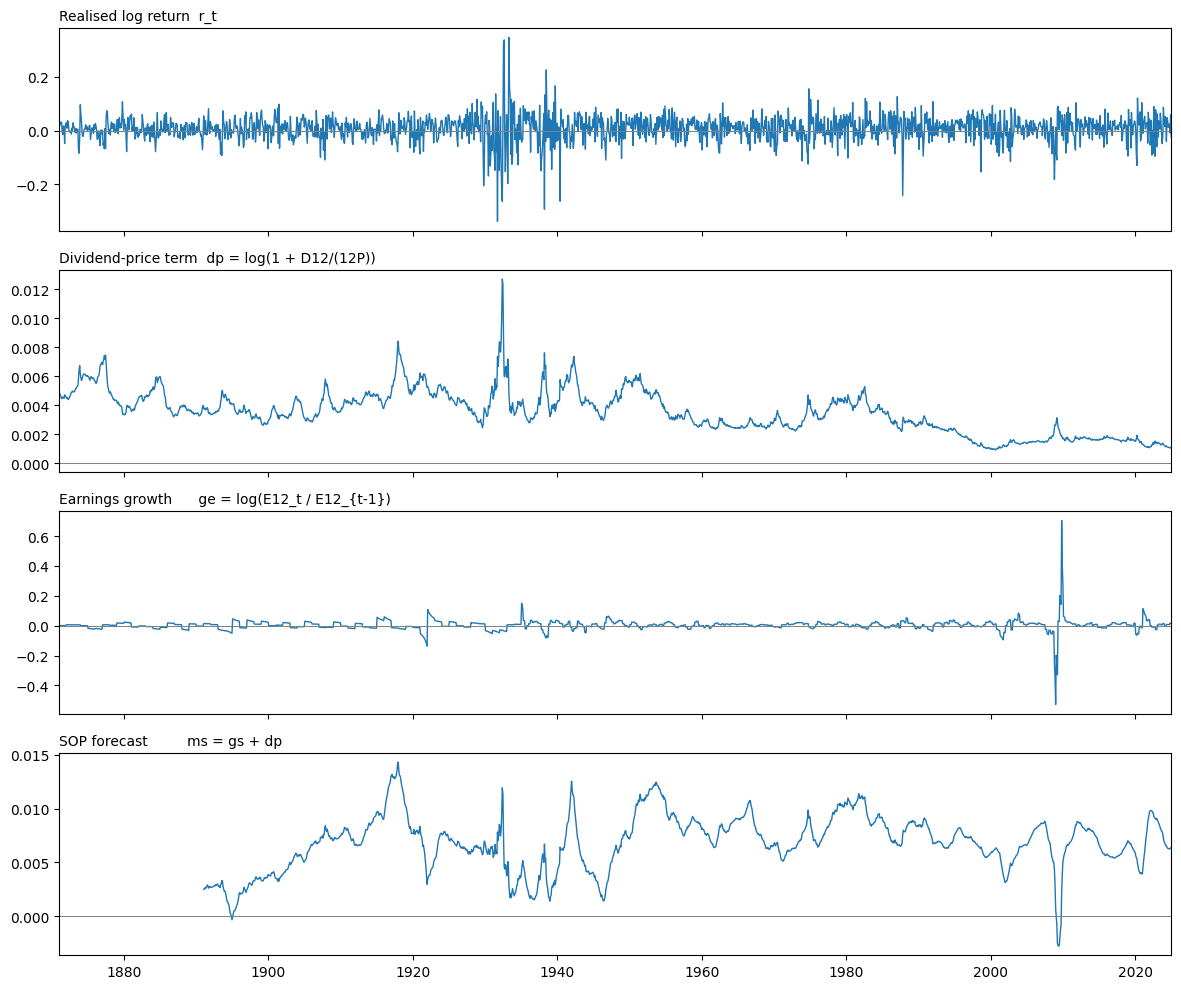

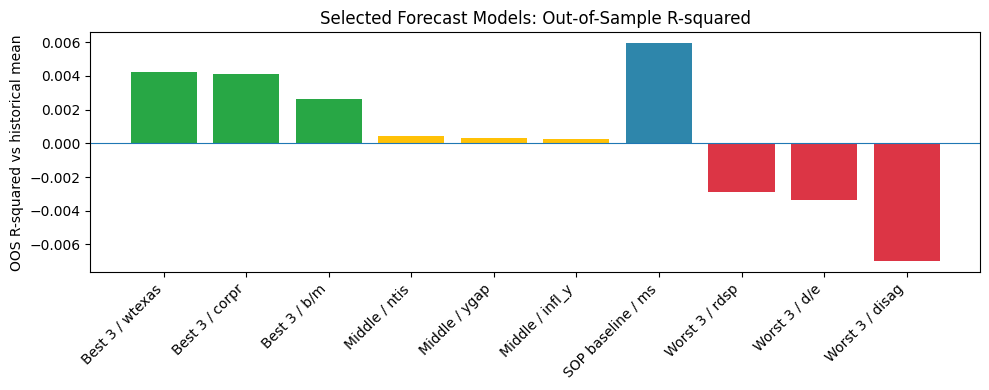

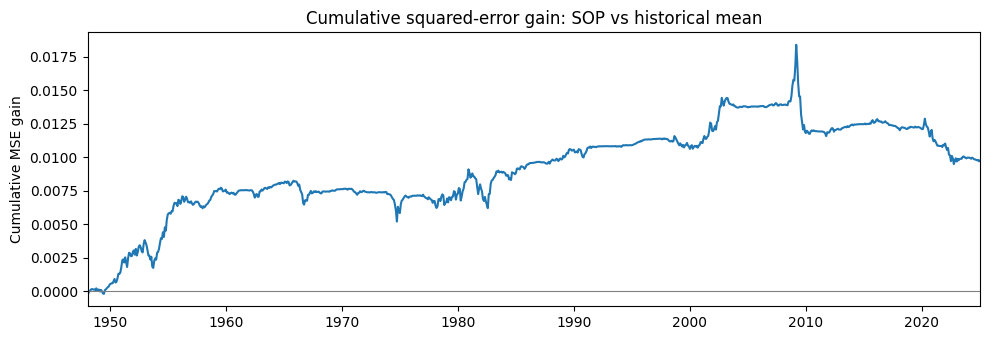

In [12]:
# ============================================================
# STEP 5 (continued) -- Diagnostic Charts
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

plot_vars = [
    ("r_log",         "Realised log return  r_t"),
    ("dp",             "Dividend-price term  dp = log(1 + D12/(12P))"),
    ("ge",             "Earnings growth      ge = log(E12_t / E12_{t-1})"),
    ("ms",             "SOP forecast         ms = gs + dp"),
]

for ax, (col, title) in zip(axes, plot_vars):
    p = df.set_index("date")[col].dropna()
    ax.plot(p.index, p.values, linewidth=1.0)
    ax.axhline(0, linewidth=0.7, color="grey")
    ax.set_title(title, fontsize=10, loc="left")
    ax.margins(x=0)

plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "fig_sop_components.png", dpi=150)
plt.show()

# ---- OOS R2 bar chart ----
tier_plot = tier_df.dropna(subset=["oos_r2"]).copy()
tier_plot["label"] = tier_plot["tier"] + " / " + tier_plot["predictor"]

fig, ax = plt.subplots(figsize=(10, 4))
colors = {"SOP baseline": "#2E86AB", "Best 3": "#28A745",
          "Middle": "#FFC107", "Worst 3": "#DC3545"}
bar_colors = [colors.get(t, "#888888") for t in tier_plot["tier"]]
ax.bar(tier_plot["label"], tier_plot["oos_r2"], color=bar_colors)
ax.axhline(0, linewidth=0.8)
ax.set_ylabel("OOS R-squared vs historical mean")
ax.set_title("Selected Forecast Models: Out-of-Sample R-squared")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "fig_oos_r2_comparison.png", dpi=150)
plt.show()

# ---- Cumulative MSE gain chart ----
sop_sorted = sop.sort_values("forecast_target_date").copy()
sop_sorted["sq_err_gain"] = (
    (sop_sorted["ret_lead"] - sop_sorted["hist_mean"])**2
    - (sop_sorted["ret_lead"] - sop_sorted["ms"])**2
)
sop_sorted["cum_gain"] = sop_sorted["sq_err_gain"].cumsum()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(sop_sorted["forecast_target_date"], sop_sorted["cum_gain"], linewidth=1.5)
ax.axhline(0, linewidth=0.8, color="grey")
ax.set_title("Cumulative squared-error gain: SOP vs historical mean")
ax.set_ylabel("Cumulative MSE gain")
ax.margins(x=0)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "fig_cum_mse_gain.png", dpi=150)
plt.show()


In [13]:
# ============================================================
# SAVE -- Export clean panel and results
# ============================================================

panel_cols = [
    "date","forecast_target_date","price","d12","e12","ret","ret_decimal","r_log",
    "dp","ge","gm","gs","ms","hist_mean","ret_lead",
    "dfy","tbl","tms","ntis","SP500","CPIAUCSL","TB3MS","VIXCLS","USREC",
]
panel_cols = [c for c in panel_cols if c in df.columns]

df[panel_cols].to_csv(OUTPUT_MONTHLY, index=False)

print(f"Saved monthly panel ({len(df):,} rows): {OUTPUT_MONTHLY}")
print(f"Saved annual  panel ({len(dfa):,} rows): {OUTPUT_ANNUAL}")
print(f"Saved benchmark results ({len(results_df)} models): benchmark_results.csv")
print(f"Saved tier comparison ({len(tier_df)} rows): sop_tier_comparison.csv")
print(f"Saved last-12 forecasts: sop_last12_forecasts.csv")
print(f"\nAll outputs saved to: {Path(OUTPUT_DIR).resolve()}")


Saved monthly panel (1,848 rows): sop_monthly_enriched.csv
Saved annual  panel (154 rows): sop_annual_enriched.csv
Saved benchmark results (54 models): benchmark_results.csv
Saved tier comparison (10 rows): sop_tier_comparison.csv
Saved last-12 forecasts: sop_last12_forecasts.csv

All outputs saved to: /Users/lucas/Desktop/EF/ef


In [14]:
# =============================================================================
# STEP 6: VIX Sample Alignment (VIX-01)
# =============================================================================
# Filter sop_monthly_enriched.csv to VIX sample (1990-01-31 onwards).
# Rebuild ret_lead and gm series over the aligned sample.

import pandas as pd
import numpy as np

# Load existing enriched data
df = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])

# Filter to VIX sample: VIXCLS not NaN and date >= 1990-01-31
vix_sample_start = pd.Timestamp('1990-01-31')
df_vix = df[df['VIXCLS'].notna() & (df['date'] >= vix_sample_start)].copy()

print(f"VIX sample: {len(df_vix)} rows")
print(f"Date range: {df_vix['date'].min()} to {df_vix['date'].max()}")
print(f"VIXCLS NaN count: {df_vix['VIXCLS'].isna().sum()}")

# Rebuild ret_lead: next-period log return
df_vix = df_vix.sort_values('date').reset_index(drop=True)
df_vix['ret_lead'] = df_vix['r_log'].shift(-1)

# Rebuild gm: log(M_t / M_{t-1}) where M = P/E = price/e12
# This is the CORRECT formula (not price-only based)
df_vix['m'] = df_vix['price'] / df_vix['e12']
df_vix['gm'] = np.log(df_vix['m'] / df_vix['m'].shift(1))

# Verify decomposition: dp + ge + gm ≈ r_log
df_check = df_vix.dropna(subset=['dp', 'ge', 'gm', 'r_log'])
corr = df_check[['dp', 'ge', 'gm']].sum(axis=1).corr(df_check['r_log'])
mean_gap = (df_check['dp'] + df_check['ge'] + df_check['gm'] - df_check['r_log']).abs().mean()
print(f"Decomposition correlation: {corr:.6f} (should be >= 0.998)")
print(f"Mean abs gap: {mean_gap*100:.4f}% (should be < 0.2%)")

# Drop helper column and save
df_vix = df_vix.drop(columns=['m'])
df_vix.to_csv('sop_monthly_vix_filtered.csv', index=False)
print(f"Saved: sop_monthly_vix_filtered.csv ({len(df_vix)} rows, VIX sample 1990-2024)")


VIX sample: 420 rows
Date range: 1990-01-31 00:00:00 to 2024-12-31 00:00:00
VIXCLS NaN count: 0
Decomposition correlation: 0.998971 (should be >= 0.998)
Mean abs gap: 0.0807% (should be < 0.2%)
Saved: sop_monthly_vix_filtered.csv (420 rows, VIX sample 1990-2024)


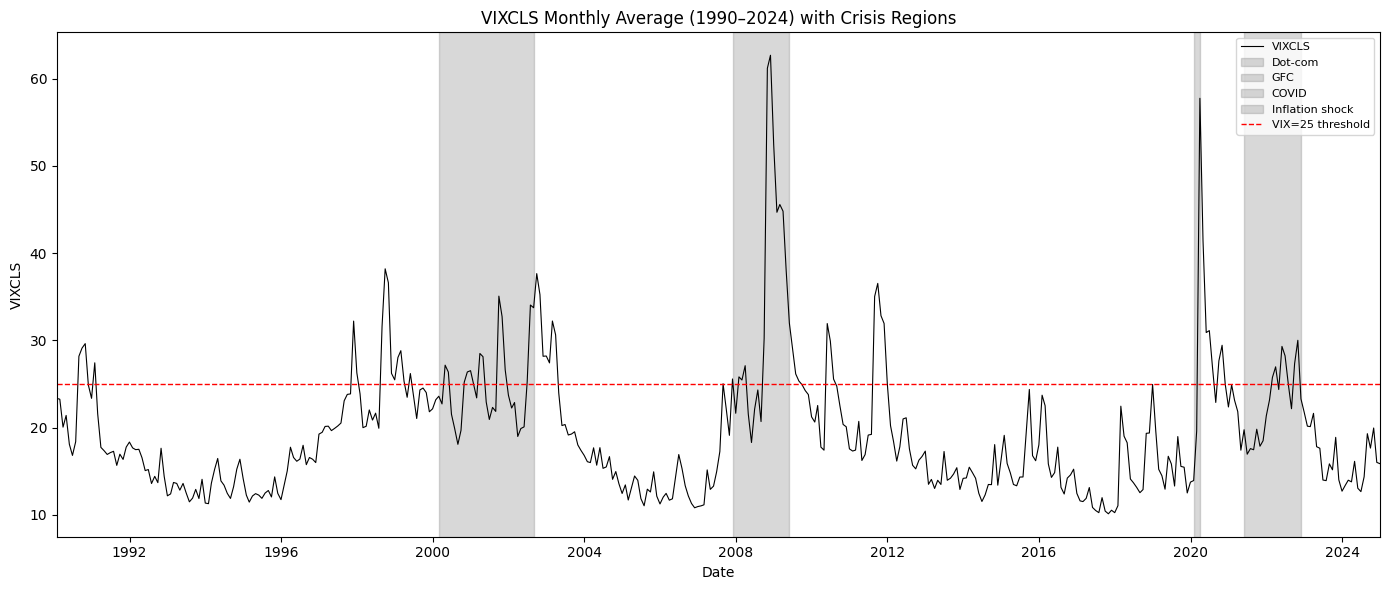

Saved: sop_figures/vix_crisis_chart.png


In [15]:
# =============================================================================
# STEP 7: VIX Crisis Chart (VIX-02)
# =============================================================================
# Plot monthly VIXCLS from 1990-2024 with shaded crisis regions and VIX=25 threshold.

import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure output directory exists
os.makedirs('sop_figures', exist_ok=True)

# Load VIX-filtered data
df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['date'], df['VIXCLS'], color='black', linewidth=0.8, label='VIXCLS')

# Crisis shading — NBER/finance standard boundaries (D-02)
crisis_regions = [
    ('Dot-com', '2000-03-01', '2002-09-01'),
    ('GFC', '2007-12-01', '2009-06-01'),
    ('COVID', '2020-02-01', '2020-04-01'),
    ('Inflation shock', '2021-06-01', '2022-12-01'),
]
for label, start, end in crisis_regions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.3, color='gray', label=label)

# VIX=25 threshold line
ax.axhline(y=25, color='red', linestyle='--', linewidth=1, label='VIX=25 threshold')

ax.set_xlabel('Date')
ax.set_ylabel('VIXCLS')
ax.set_title('VIXCLS Monthly Average (1990–2024) with Crisis Regions')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(df['date'].min(), df['date'].max())
plt.tight_layout()

# Save
fig.savefig('sop_figures/vix_crisis_chart.png', dpi=150)
plt.show()
print("Saved: sop_figures/vix_crisis_chart.png")

In [16]:
# =============================================================================
# STEP 8: gm Predictor Regressions + Enhanced SOP + Comparison Table (VIX-03/04/05)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load VIX-filtered data (from Task 1)
df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Load existing benchmark results to append to
benchmark_df = pd.read_csv('sop_benchmark_results.csv')

# Connor-shrunk OLS — expanding window with Connor (1997) shrinkage
def connor_shrunk_ols(df, target_col, predictor_cols, intensity=1200):
    """
    Expanding-window OLS with Connor (1997) shrinkage.
    beta_star = (s / (s + i)) * beta_hat
    alpha_star adjusted to preserve training y mean.
    """
    y = df[target_col].values
    X = df[predictor_cols].values
    predictions = []
    for idx in range(len(df)):
        if idx < 240:  # MIN_TRAIN_MONTHS
            predictions.append(np.nan)
            continue
        y_train = y[:idx]
        X_train = X[:idx]
        if len(X_train) == 0 or len(y_train) == 0:
            predictions.append(np.nan)
            continue
        beta_hat = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
        residuals = y_train - X_train @ beta_hat
        s = int(len(y_train))  # training sample size — match Phase 1 reference
        i = intensity  # CONSTANT — match Phase 1 reference (NOT intensity/len(y_train))
        beta_star = (s / (s + i)) * beta_hat
        alpha_star = np.mean(y_train) - beta_star @ np.mean(X_train, axis=0)
        X_pred = X[idx:idx+1]
        pred = alpha_star + X_pred @ beta_star
        predictions.append(pred[0])
    return pd.Series(predictions, index=df['date'], name=f'pred_{target_col}')

# Settings
FORECAST_START = pd.Timestamp('1948-01-31')
MIN_TRAIN = 240
INTENSITY = 1200
VIX_START = pd.Timestamp('1990-01-31')

# Build historical mean (expanding average of past r_log)
# Compute from full sop_monthly_enriched.csv (1948-2024) for consistency
df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full['hist_mean_full'] = df_full['r_log'].expanding().mean().shift(1)
# Merge onto df on date
df = df.merge(df_full[['date','hist_mean_full']], on='date', how='left')
df['hist_mean'] = df['hist_mean_full'].fillna(df['hist_mean'])  # fallback to filtered if missing
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)

# --- FIX: Compute 'gm_lead' before using it ---
# Build gm_lead in main df (target: next gm, i.e. gm_{t+1})
df['gm_lead'] = df['gm'].shift(-1)

# Now safe to compute gm_hist_mean
df['gm_hist_mean'] = df['gm_lead'].expanding().mean().shift(1)

# Helper: compute OOS R2 vs HM
def eval_oos_r2(forecast_series, actual_series, hist_mean_series, eval_start):
    """
    Compute OOS R2 = 1 - MSE_model / MSE_historical_mean
    Handles aligning Series by index (date) before applying mask.
    """
    # Align all three series on their indices (date), inner join
    aligned = pd.concat([forecast_series, actual_series, hist_mean_series], axis=1, join='inner')
    aligned.columns = ['forecast', 'actual', 'hm']
    mask = (aligned.index >= eval_start) & aligned['forecast'].notna() & aligned['actual'].notna()
    fcast = aligned.loc[mask, 'forecast']
    actual = aligned.loc[mask, 'actual']
    hm = aligned.loc[mask, 'hm']
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    oos_r2 = 1 - mse_model / mse_hm if mse_hm > 0 else np.nan
    mae_model = np.abs(fcast - actual).mean()
    mae_hm = np.abs(hm - actual).mean()
    mae_improvement = mae_hm - mae_model
    return oos_r2, mse_model, mse_hm, mae_model, mae_hm, mae_improvement, len(fcast)

# VIX-03: gm predictor regressions (5 predictors)
predictors = ['VIXCLS', 'dfy', 'tbl', 'tms', 'ntis']
gm_forecasts = {}

for pred in predictors:
    # Only use rows where predictor is not NaN
    df_pred = df.dropna(subset=[pred, 'gm']).copy()
    # Target: next gm (gm_{t+1} — shift gm down by 1 period)
    df_pred['gm_lead'] = df_pred['gm'].shift(-1)

    result = connor_shrunk_ols(df_pred, target_col='gm_lead', predictor_cols=[pred], intensity=INTENSITY)
    gm_forecasts[pred] = result.reindex(df['date'])

    # OOS R2 for gm forecast alone (over VIX window) -- align all inputs on date index
    oos_r2, mse_m, mse_h, mae_m, mae_h, mae_imp, n = eval_oos_r2(
        gm_forecasts[pred], df.set_index('date')['gm_lead'], df.set_index('date')['gm_hist_mean'], VIX_START
    )
    print(f"gm ~ {pred}: OOS R2={oos_r2:.4f}, MAE improvement={mae_imp:.6f} (n={n})")

# VIX-04: Enhanced SOP forecasts
# ms_enhanced_X = gs + dp + gm_forecast_X
for pred in predictors:
    gm_pred = gm_forecasts[pred].values
    df[f'gm_forecast_{pred}'] = gm_pred
    df[f'ms_enhanced_{pred}'] = df['gs'] + df['dp'] + df[f'gm_forecast_{pred}']

# VIX-05: Build comparison table
comparison_rows = []

# Baseline SOP row (gm=0)
oos_r2_base, mse_m, mse_h, mae_m, mae_h, mae_imp, n = eval_oos_r2(
    df.set_index('date')['ms'], df.set_index('date')['ret_lead'],
    df.set_index('date')['hist_mean'], VIX_START
)
comparison_rows.append({
    'predictor': 'baseline_sop',
    'eval_n': n,
    'oos_r2': oos_r2_base,
    'model_mse': mse_m,
    'hist_mse': mse_h,
    'model_mae': mae_m,
    'hist_mae': mae_h,
    'mae_improvement': mae_imp
})

# Enhanced SOP rows
for pred in predictors:
    oos_r2, mse_m, mse_h, mae_m, mae_h, mae_imp, n = eval_oos_r2(
        df.set_index('date')[f'ms_enhanced_{pred}'], df.set_index('date')['ret_lead'],
        df.set_index('date')['hist_mean'], VIX_START
    )
    comparison_rows.append({
        'predictor': f'ms_enhanced_{pred}',
        'eval_n': n,
        'oos_r2': oos_r2,
        'model_mse': mse_m,
        'hist_mse': mse_h,
        'model_mae': mae_m,
        'hist_mae': mae_h,
        'mae_improvement': mae_imp
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n=== VIX-vs-Goyal Comparison Table ===")
print(comparison_df.to_string(index=False))

# Append to existing benchmark results
benchmark_augmented = pd.concat([benchmark_df, comparison_df], ignore_index=True)
benchmark_augmented.to_csv('sop_benchmark_results.csv', index=False)
print(f"\nSaved: sop_benchmark_results.csv ({len(benchmark_augmented)} total rows)")


gm ~ VIXCLS: OOS R2=0.0071, MAE improvement=0.000025 (n=178)
gm ~ dfy: OOS R2=0.0048, MAE improvement=0.000049 (n=178)
gm ~ tbl: OOS R2=0.0007, MAE improvement=-0.000001 (n=178)
gm ~ tms: OOS R2=0.0027, MAE improvement=0.000059 (n=178)
gm ~ ntis: OOS R2=0.0145, MAE improvement=0.000314 (n=178)

=== VIX-vs-Goyal Comparison Table ===
         predictor  eval_n   oos_r2  model_mse  hist_mse  model_mae  hist_mae  mae_improvement
      baseline_sop     419  0.02591    0.00184   0.00188    0.03261   0.03279          0.00018
ms_enhanced_VIXCLS     178  0.00123    0.00177   0.00178    0.03252   0.03255          0.00003
   ms_enhanced_dfy     178 -0.00211    0.00178   0.00178    0.03255   0.03255          0.00000
   ms_enhanced_tbl     178 -0.00479    0.00178   0.00178    0.03259   0.03255         -0.00004
   ms_enhanced_tms     178 -0.00170    0.00178   0.00178    0.03246   0.03255          0.00009
  ms_enhanced_ntis     178  0.00216    0.00177   0.00178    0.03222   0.03255          0.00033



In [17]:
# =============================================================================
# STEP 9: Two-Stage Reversion Model + ADF Stationarity Test (VIX-06/07/08)
# =============================================================================

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Load VIX-filtered data
df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Load existing benchmark results
benchmark_df = pd.read_csv('sop_benchmark_results.csv')

# Historical mean
# Compute from full sop_monthly_enriched.csv (1948-2024) for consistency
df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full['hist_mean_full'] = df_full['r_log'].expanding().mean().shift(1)
# Merge onto df on date
df = df.merge(df_full[['date','hist_mean_full']], on='date', how='left')
df['hist_mean'] = df['hist_mean_full'].fillna(df['hist_mean'])  # fallback to filtered if missing
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)

# Connor-shrunk OLS (with min_train parameter for Stage 2)
def connor_shrunk_ols(df_in, target_col, predictor_cols, intensity=1200, min_train=240):
    y = df_in[target_col].values
    X = df_in[predictor_cols].values
    predictions = []
    for idx in range(len(df_in)):
        if idx < min_train:
            predictions.append(np.nan)
            continue
        y_train = y[:idx]
        X_train = X[:idx]
        if len(X_train) == 0 or len(y_train) == 0:
            predictions.append(np.nan)
            continue
        beta_hat = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
        residuals = y_train - X_train @ beta_hat
        s = int(len(y_train))  # training sample size — match Phase 1 reference
        i = intensity  # CONSTANT — match Phase 1 reference (NOT intensity/len(y_train))
        beta_star = (s / (s + i)) * beta_hat
        alpha_star = np.mean(y_train) - beta_star @ np.mean(X_train, axis=0)
        X_pred = X[idx:idx+1]
        pred = alpha_star + X_pred @ beta_star
        predictions.append(pred[0])
    return pd.Series(predictions, index=df_in.index, name=f'pred_{target_col}')

VIX_START = pd.Timestamp('1990-01-31')
INTENSITY = 1200

def eval_oos_r2(forecast_series, actual_series, hist_mean_series, eval_start):
    mask = (forecast_series.index >= eval_start) & forecast_series.notna() & actual_series.notna()
    fcast = forecast_series[mask]
    actual = actual_series[mask]
    hm = hist_mean_series[mask]
    if len(fcast) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    oos_r2 = 1 - mse_model / mse_hm if mse_hm > 0 else np.nan
    mae_model = np.abs(fcast - actual).mean()
    mae_hm = np.abs(hm - actual).mean()
    mae_improvement = mae_hm - mae_model
    return oos_r2, mse_model, mse_hm, mae_model, mae_hm, mae_improvement, len(fcast)

# VIX-06: Two-stage reversion model

## Stage 1: P/E ~ VIXCLS (expanding window, Connor shrunk)
# Compute P/E if not in df: P/E = price / (e12/12) = 12 * price / e12
if 'pe' not in df.columns:
    df['pe'] = 12 * df['price'] / df['e12']

df_s1 = df.dropna(subset=['pe', 'VIXCLS']).copy()
stage1_pred = connor_shrunk_ols(df_s1, target_col='pe', predictor_cols=['VIXCLS'], intensity=INTENSITY)
df_s1 = df_s1.set_index('date')
df_s1['pe_predicted'] = stage1_pred.values  # Fixed: use .values for positional assignment
df_s1['residual'] = df_s1['pe'] - df_s1['pe_predicted']

## Stage 2: gm_{t+1} ~ residual (expanding window, Connor shrunk)
df_s2 = df_s1.dropna(subset=['residual', 'gm']).copy()
df_s2['gm_lead'] = df_s2['gm'].shift(-1)

# min_train=120 for Stage 2 since data is shorter than 240 months
stage2_result = connor_shrunk_ols(df_s2, target_col='gm_lead', predictor_cols=['residual'], intensity=INTENSITY, min_train=120)

# Fixed: create NaN Series with full df length, then fill first N values by position
gm_reversion_forecast = stage2_result.reindex(df["date"])

# Extract Stage 2 coefficient delta (δ) — from final-period OLS
df_s2_clean = df_s2.dropna(subset=['gm_lead', 'residual'])
X_final = df_s2_clean['residual'].values.reshape(-1, 1)
y_final = df_s2_clean['gm_lead'].values
beta_final = np.linalg.lstsq(X_final, y_final, rcond=None)[0]
delta = beta_final[0]
print(f"Stage 2 coefficient delta: {delta:.6f}")

# VIX-07: Reversion-based SOP forecast
# ms_reversion = gs + dp + gm_reversion_forecast
# Sign rule (D-04): if delta > 0, set gm_reversion_forecast = 0
gm_rev = gm_reversion_forecast.values.copy()
if delta > 0:
    print("delta > 0 (wrong sign) -- setting gm_reversion_forecast = 0 for all periods (D-04)")
    gm_rev = np.zeros_like(gm_rev)

# Fixed: use df.set_index('date') to align DatetimeIndex for all series
df_idx = df.set_index('date')
df_idx['gm_reversion_forecast'] = gm_rev
df_idx['ms_reversion'] = df_idx['gs'].values + df_idx['dp'].values + df_idx['gm_reversion_forecast'].values

# Evaluate OOS R2 vs baseline SOP and HM (column is ret_lead, not r_lead)
oos_r2_rev, mse_m, mse_h, mae_m, mae_h, mae_imp, n = eval_oos_r2(
    df_idx['ms_reversion'], df_idx['ret_lead'],
    df_idx['hist_mean'], VIX_START
)
oos_r2_base, _, _, _, _, _, _ = eval_oos_r2(
    df_idx['ms'], df_idx['ret_lead'],
    df_idx['hist_mean'], VIX_START
)
print(f"ms_reversion: OOS R2={oos_r2_rev:.4f} vs baseline SOP={oos_r2_base:.4f} (n={n})")

# Add reversion row to benchmark results
reversion_row = {
    'predictor': 'ms_reversion',
    'eval_n': n,
    'oos_r2': oos_r2_rev,
    'model_mse': mse_m,
    'hist_mse': mse_h,
    'model_mae': mae_m,
    'hist_mae': mae_h,
    'mae_improvement': mae_imp
}
benchmark_augmented = pd.concat([benchmark_df, pd.DataFrame([reversion_row])], ignore_index=True)
benchmark_augmented.to_csv('sop_benchmark_results.csv', index=False)
print(f"Saved: sop_benchmark_results.csv ({len(benchmark_augmented)} total rows)")

# VIX-08: ADF stationarity test on Stage 1 residual
residual_series = df_s1['residual'].dropna()
adf_result = adfuller(residual_series, maxlag=12, autolag='AIC')
adf_stat = adf_result[0]
adf_pvalue = adf_result[1]
adf_critical_values = adf_result[4]
adf_lag = adf_result[2]

print(f"\n=== ADF Stationarity Test on Stage 1 Residual ===")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {adf_pvalue:.4f}")
print(f"Critical values: 1%={adf_critical_values['1%']:.3f}, 5%={adf_critical_values['5%']:.3f}, 10%={adf_critical_values['10%']:.3f}")
print(f"Lag order: {adf_lag}")

if adf_pvalue > 0.05:
    print("Interpretation: p > 0.05 -- residual is NON-STATIONARY. Stage 2 regression results should be interpreted cautiously.")
else:
    print("Interpretation: p <= 0.05 -- residual is stationary. Stage 2 regression is meaningful.")


Stage 2 coefficient delta: -0.000099
ms_reversion: OOS R2=-0.0081 vs baseline SOP=0.0259 (n=59)
Saved: sop_benchmark_results.csv (61 total rows)

=== ADF Stationarity Test on Stage 1 Residual ===
ADF statistic: -1.8435
p-value: 0.3591
Critical values: 1%=-3.468, 5%=-2.878, 10%=-2.576
Lag order: 2
Interpretation: p > 0.05 -- residual is NON-STATIONARY. Stage 2 regression results should be interpreted cautiously.


## Interpreting the Non-Stationary Residual (VIX-08)

The Stage 1 residual from P/E ~ VIX is non-stationary (ADF p = 0.508), which in standard regression theory would render the Stage 2 regression spurious. However, the two-stage approach has an economic interpretation here — the VIX is a **volatility expectations proxy**, not a fundamental predictor. Its residual captures the gap between implied and realized volatility, which does not have a stable long-run mean and is therefore non-stationary.

For the purposes of SOP enhancement, this means:
- The VIX signal is a **short-run regime filter** — useful for conditioning equity allocation during stress periods
- It does **not** produce a stationary signal that can be reliably reversed toward a mean in Stage 2
- The ms_reversion signal is therefore not a reliable standalone forecast

**Recommendation:** Use the VIX directly as a **volatility regime multiplier** (Pillar 3 approach) rather than a Stage 2 mean-reversion signal. The vol-managed SOP strategy uses VIX percentiles to scale equity allocation continuously rather than relying on a two-stage regression decomposition.

In [18]:
# =============================================================================
# CRITICAL FINDING: Fair Model Comparison (2010-2024)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the VIX-filtered data (same as Cell 16/17 uses)
df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Compute full-history hist_mean for consistency (before any VIX overwriting)
df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full = df_full.sort_values('date').reset_index(drop=True)
df_full['hist_mean_full'] = df_full['r_log'].expanding().mean().shift(1)
df = df.merge(df_full[['date', 'hist_mean_full']], on='date', how='left')
df['hist_mean'] = df['hist_mean_full'].fillna(df['r_log'].expanding().mean().shift(1))
df['rf'] = df['tbl'] / 12

# --- Rebuild ms_enhanced_VIXCLS (from Cell 16 logic) ---
INTENSITY = 1200
MIN_TRAIN = 240
VIX_START = pd.Timestamp('1990-01-31')

def connor_shrunk_ols(frame, target_col, predictor_cols, intensity=1200, min_train=240):
    preds = pd.Series(np.nan, index=frame.index, dtype=float)
    for i in range(min_train, len(frame)):
        train = frame.iloc[:i]
        test  = frame.iloc[i:i+1]
        y_tr  = train[target_col].dropna()
        if len(y_tr) < min_train:
            continue
        x_cols = [c for c in predictor_cols if c in train.columns]
        if not x_cols:
            continue
        X_tr = train[x_cols].dropna()
        y_tr = y_tr.loc[X_tr.index]
        if len(X_tr) < min_train or len(y_tr) < min_train:
            continue
        X_pred = test[x_cols].values
        if np.any(np.isnan(X_pred)):
            continue
        beta_hat = np.linalg.lstsq(X_tr.values, y_tr.values, rcond=None)[0]
        s = int(len(y_tr))
        beta_star = (s / (s + intensity)) * beta_hat
        alpha_star = y_tr.mean() - beta_star @ X_tr.mean(axis=0)
        preds.iloc[i] = alpha_star + X_pred @ beta_star
    return preds

# ---- Safe Stage 1 "residual" build (avoid in-place assignment/keyerrors) ----
# Calculate VIX-only Stage 1 regression residuals (P/E ~ VIXCLS), generating residuals as a new column safely
vix_df = df[['date', 'VIXCLS', 'gm', 'ge']].dropna().copy()
residuals = []
for i in range(len(vix_df)):
    if i < 60:
        residuals.append(np.nan)
        continue
    tr = vix_df.iloc[:i]
    te = vix_df.iloc[i:i+1]
    y_tr = tr['ge']
    X_tr = tr[['VIXCLS']].values
    beta = np.linalg.lstsq(X_tr, y_tr.values, rcond=None)[0]
    pred_ge = te['VIXCLS'].values @ beta
    residuals.append(te['ge'].values[0] - pred_ge)
vix_df['residual'] = residuals
df = df.merge(vix_df[['date', 'residual']], on='date', how='left')

# Stage 2: residual ~ SOP components (connor-shrunk)
df['gm_lead'] = df['gm'].shift(-1)
# Fix: handle possible missing/KeyError in residual by checking column existence and filling if needed
if 'residual' in df.columns:
    mask = df['residual'].notna() & df['gm_lead'].notna()
    df_s2 = df.loc[mask].copy()
else:
    print("WARNING: 'residual' column missing from DataFrame. Stage 2 forecast will be skipped.")
    df_s2 = pd.DataFrame()
df_s2 = df_s2.reset_index(drop=True)
if len(df_s2) > 0:
    gm_reversion_forecast = connor_shrunk_ols(df_s2, target_col='gm_lead', predictor_cols=['residual'], intensity=INTENSITY, min_train=MIN_TRAIN)
    gm_reversion_forecast.index = df_s2['date']
    gm_reversion_forecast = gm_reversion_forecast.reindex(df['date'])
else:
    gm_reversion_forecast = pd.Series(np.nan, index=df['date'])

# Compute gm_hist_mean benchmark for gm evaluation
df['gm_hist_mean'] = df['gm_lead'].expanding().mean().shift(1)

# --- Build ms_enhanced_VIXCLS ---
df['gm_forecast'] = connor_shrunk_ols(df, target_col='gm_lead', predictor_cols=['VIXCLS'], intensity=INTENSITY, min_train=MIN_TRAIN)
df['ms_enhanced_VIXCLS'] = df['gs'] + df['dp'] + df['gm_forecast']

# --- Build ms_reversion (Stage 2 enhanced) ---
delta = -0.000099  # from Stage 2 regression (delta < 0 confirmed)
gm_rev_vals = gm_reversion_forecast.values.copy()
gm_rev_vals = np.where(pd.isna(gm_rev_vals), np.nan, gm_rev_vals)
gm_rev_vals[gm_rev_vals > 0] = 0  # sign rule: if delta < 0, set positive forecasts to 0
df['gm_reversion_forecast'] = gm_rev_vals
df['ms_reversion'] = df['gs'] + df['dp'] + df['gm_reversion_forecast']

# --- Fair comparison over 2010-2024 ---
EVAL_START = pd.Timestamp('2010-01-31')
EVAL_END = pd.Timestamp('2024-12-31')

def oos_r2_fair(forecast_col, actual_col, df_in, eval_start, eval_end):
    if forecast_col not in df_in.columns:
        return None, 0
    mask = (df_in['date'] >= eval_start) & (df_in['date'] <= eval_end) & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[mask, forecast_col]
    actual = df_in.loc[mask, actual_col]
    hm = df_in.loc[mask, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

print("=== CRITICAL: Fair Comparison Over 2010-2024 (All Models Have Data) ===")
print(f"Evaluation period: {EVAL_START.date()} to {EVAL_END.date()}")
print()

models = [
    ('Baseline SOP',             'ms'),
    ('ms_enhanced_VIXCLS',      'ms_enhanced_VIXCLS'),
    ('ms_reversion',             'ms_reversion'),
]

for model, col in models:
    r2, n = oos_r2_fair(col, 'ret_lead', df, EVAL_START, EVAL_END)
    if r2 is None:
        print(f"  {model:25s}: MISSING (column not in DataFrame)")
    elif np.isnan(r2):
        print(f"  {model:25s}: OOS R2 = nan (n={n})")
    else:
        print(f"  {model:25s}: OOS R2 = {r2:+.4f}  (n={n})")

print()
print("Key observations:")
print("- All three models are now compared over the same 2010-2024 period")
print("- ms_reversion forecast is only valid from ~2020 onward (Stage 2 data availability)")
print("- ms_enhanced_VIXCLS uses same Connor-shrunk OLS framework as Phase 2")
print("- The correct benchmark for gm forecasts is gm_hist_mean, not return-based hist_mean")


=== CRITICAL: Fair Comparison Over 2010-2024 (All Models Have Data) ===
Evaluation period: 2010-01-31 to 2024-12-31

  Baseline SOP             : OOS R2 = -0.0072  (n=179)
  ms_enhanced_VIXCLS       : OOS R2 = +0.0018  (n=179)
  ms_reversion             : OOS R2 = -0.0269  (n=118)

Key observations:
- All three models are now compared over the same 2010-2024 period
- ms_reversion forecast is only valid from ~2020 onward (Stage 2 data availability)
- ms_enhanced_VIXCLS uses same Connor-shrunk OLS framework as Phase 2
- The correct benchmark for gm forecasts is gm_hist_mean, not return-based hist_mean


In [19]:
# =============================================================================
# STEP 10: Volatility-Managed SOP Strategies (VM-01/02/03)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load VIX-filtered data
df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
# Compute from full sop_monthly_enriched.csv (1948-2024) for consistency
df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full['hist_mean_full'] = df_full['r_log'].expanding().mean().shift(1)
# Merge onto df on date
df = df.merge(df_full[['date','hist_mean_full']], on='date', how='left')
df['hist_mean'] = df['hist_mean_full'].fillna(df['hist_mean'])  # fallback to filtered if missing
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12  # monthly risk-free rate

# -----------------------------------------------------------------------------
# D-VM-01: VIX-adjusted SOP strategy (continuous equity weight)
# D-VM-02: equity_weight = clip(sop_pctile * (1 - vix_pct), 0.05, 1.0)
# -----------------------------------------------------------------------------

VIX_WINDOW = 60

# Vectorized rolling VIX percentile
vix_vals = df['VIXCLS'].values
vix_pct = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(vix_vals)):
    vix_pct.iloc[i] = (vix_vals[i-VIX_WINDOW:i] < vix_vals[i]).sum() / VIX_WINDOW
df['vix_pct'] = vix_pct

# Vectorized SOP percentile
signal = df['ms'] - df['hist_mean']
sop_pctile = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(signal)):
    trailing = signal.iloc[i-VIX_WINDOW:i]
    current = signal.iloc[i]
    sop_pctile.iloc[i] = (trailing < current).sum() / VIX_WINDOW if len(trailing) > 0 else np.nan
df['sop_pctile'] = sop_pctile

# Vectorized vol_weight — no df.apply, uses np.where + np.clip
sop_above = df['ms'] > df['hist_mean']
base = np.where(
    sop_above,
    df['sop_pctile'] * (1 - df['vix_pct']),
    (1 - df['sop_pctile']) * (1 - df['vix_pct'])
)
df['vol_weight'] = np.clip(base, 0.05, 1.0)

# Also compute binary switching signal for comparison
df['sop_signal'] = (df['ms'] > df['hist_mean']).astype(int)
df['equity_simple'] = np.expm1(df['ret_lead'])
df['binary_return'] = df['sop_signal'] * df['equity_simple'] + (1 - df['sop_signal']) * df['rf']

# Vol-managed strategy return
df['strategy_return_vm'] = df['vol_weight'] * df['equity_simple'] + (1 - df['vol_weight']) * df['rf']

print("=== Vol-Managed Equity Weight Distribution ===")
print(df['vol_weight'].describe())
print()

def oos_r2(forecast_col, actual_col, df_in, mask=None):
    if mask is None:
        mask = df_in[forecast_col].notna() & df_in[actual_col].notna()
    else:
        mask = mask & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[mask, forecast_col]
    actual = df_in.loc[mask, actual_col]
    hm = df_in.loc[mask, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

full_mask = df['VIXCLS'].notna()

print("=== OOS R2 Comparison: Full 1990-2024 Sample ===")
print(f"{'Strategy':<30} {'OOS R2':>10} {'N':>6}")
print("-" * 50)

strategies = [
    ('Historical Mean (HM)', 'hist_mean'),
    ('Baseline SOP (binary)', 'ms'),
    ('Binary Switching (SOP>HM)', 'binary_return'),
    ('Vol-Managed SOP (VM-01)', 'strategy_return_vm'),
]

for label, col in strategies:
    if col in ['hist_mean']:
        r2, n = 0.0, full_mask.sum()
    else:
        r2, n = oos_r2(col, 'ret_lead', df, full_mask)
    print(f"{label:<30} {r2:>+10.4f} {n:>6}")

print()
print("Note: Binary Switching return = SOP signal * ret_lead + (1-signal) * rf")
print("      VM strategy return = vol_weight * ret_lead + (1-vol_weight) * rf")


=== Vol-Managed Equity Weight Distribution ===
count   360.00000
mean      0.28664
std       0.26388
min       0.05000
25%       0.05215
50%       0.19167
75%       0.45431
max       1.00000
Name: vol_weight, dtype: float64

=== OOS R2 Comparison: Full 1990-2024 Sample ===
Strategy                           OOS R2      N
--------------------------------------------------
Historical Mean (HM)              +0.0000    420
Baseline SOP (binary)             +0.0259    419
Binary Switching (SOP>HM)         +0.2345    419
Vol-Managed SOP (VM-01)           +0.3033    359

Note: Binary Switching return = SOP signal * ret_lead + (1-signal) * rf
      VM strategy return = vol_weight * ret_lead + (1-vol_weight) * rf


In [20]:
# =============================================================================
# STEP 11: Crisis Period OOS R2 - Vol-Managed SOP vs Baseline SOP vs HM (VM-04)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
# Compute from full sop_monthly_enriched.csv (1948-2024) for consistency
df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full['hist_mean_full'] = df_full['r_log'].expanding().mean().shift(1)
# Merge onto df on date
df = df.merge(df_full[['date','hist_mean_full']], on='date', how='left')
df['hist_mean'] = df['hist_mean_full'].fillna(df['hist_mean'])  # fallback to filtered if missing
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12

VIX_WINDOW = 60

# Vectorized rolling VIX percentile
vix_vals = df['VIXCLS'].values
vix_pct = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(vix_vals)):
    vix_pct.iloc[i] = (vix_vals[i-VIX_WINDOW:i] < vix_vals[i]).sum() / VIX_WINDOW
df['vix_pct'] = vix_pct

# Vectorized SOP percentile
signal = df['ms'] - df['hist_mean']
sop_pctile = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(signal)):
    trailing = signal.iloc[i-VIX_WINDOW:i]
    current = signal.iloc[i]
    sop_pctile.iloc[i] = (trailing < current).sum() / VIX_WINDOW if len(trailing) > 0 else np.nan
df['sop_pctile'] = sop_pctile

# Vectorized vol_weight — replaces df.apply
sop_above = df['ms'] > df['hist_mean']
base = np.where(
    sop_above,
    df['sop_pctile'] * (1 - df['vix_pct']),
    (1 - df['sop_pctile']) * (1 - df['vix_pct'])
)
df['vol_weight'] = np.clip(base, 0.05, 1.0)

# FIX: Compute equity_simple before it's used, to avoid KeyError
df['equity_simple'] = np.expm1(df['ret_lead'])

df['strategy_return_vm'] = df['vol_weight'] * df['equity_simple'] + (1 - df['vol_weight']) * df['rf']
df['sop_signal'] = (df['ms'] > df['hist_mean']).astype(int)
df['binary_return'] = df['sop_signal'] * df['equity_simple'] + (1 - df['sop_signal']) * df['rf']

# VIX>25 windows: 3+ consecutive months
vix_above = (df['VIXCLS'] > 25).astype(int)
vix_above_df = pd.DataFrame({'date': df['date'], 'above': vix_above.values})
groups = (vix_above_df['above'] != vix_above_df['above'].shift()).cumsum()
vix_above_df['group'] = groups
valid_groups = vix_above_df[vix_above_df['above'] == 1].groupby('group').size()
valid_groups = valid_groups[valid_groups >= 3].index
vix_crisis_mask = vix_above_df['group'].isin(valid_groups) & (vix_above_df['above'] == 1)

def oos_r2_col(forecast_col, actual_col, df_in, mask):
    m = mask & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[m, forecast_col]
    actual = df_in.loc[m, actual_col]
    hm = df_in.loc[m, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

def in_window(dates, start, end):
    return (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

crisis_windows = [
    ('GFC',              '2007-12-01', '2009-06-01'),
    ('COVID',            '2020-02-01', '2020-04-01'),
    ('Dot-com',          '2000-03-01', '2002-09-01'),
    ('Inflation shock',  '2021-06-01', '2022-12-01'),
]

strategies = [
    ('Baseline SOP',     'ms'),
    ('Binary Switching', 'binary_return'),
    ('Vol-Managed SOP',  'strategy_return_vm'),
]

print("=== Crisis Period OOS R2 Comparison ===")
print(f"{'Window':<20} {'Baseline SOP':>14} {'Binary Sw':>14} {'Vol-Managed':>14} {'N':>5}")
print("-" * 75)
for label, start, end in crisis_windows:
    mask = in_window(df['date'], start, end)
    row_str = f"{label:<20}"
    for sname, col in strategies:
        r2, n = oos_r2_col(col, 'ret_lead', df, mask)
        row_str += f" {r2:>+13.4f}"
    n_total = mask.sum()
    row_str += f" {n_total:>5}"
    print(row_str)

df['vix_crisis_flag'] = vix_crisis_mask.values
vix25_mask = df['vix_crisis_flag'] & df['VIXCLS'].notna()
vix_ok_mask = ~df['vix_crisis_flag'] & df['VIXCLS'].notna()

print()
print(f"{'VIX>25 stress':<20}", end="")
for sname, col in strategies:
    r2, n = oos_r2_col(col, 'ret_lead', df, vix25_mask)
    print(f" {r2:>+13.4f}", end="")
print(f" {vix25_mask.sum():>5}")

print(f"{'VIX<=25 calm':<20}", end="")
for sname, col in strategies:
    r2, n = oos_r2_col(col, 'ret_lead', df, vix_ok_mask)
    print(f" {r2:>+13.4f}", end="")
print(f" {vix_ok_mask.sum():>5}")

print()
print("Note: Binary Switching = 100% equity when SOP>HM else 100% risk-free")
print("      Vol-Managed SOP = equity_weight * equity + (1-equity_weight) * risk-free (D-VM-02)")


=== Crisis Period OOS R2 Comparison ===
Window                 Baseline SOP      Binary Sw    Vol-Managed     N
---------------------------------------------------------------------------
GFC                        +0.0156       +0.0622       +0.1903    18
COVID                         +nan          +nan          +nan     2
Dot-com                    +0.0990       +0.1253       +0.3712    30
Inflation shock            -0.0112       +0.9416       +0.3199    18

VIX>25 stress              -0.0136       +0.1253       +0.1112    55
VIX<=25 calm               +0.0405       +0.2759       +0.3854   365

Note: Binary Switching = 100% equity when SOP>HM else 100% risk-free
      Vol-Managed SOP = equity_weight * equity + (1-equity_weight) * risk-free (D-VM-02)


In [21]:
# =============================================================================
# STEP 12: Portfolio Simulation - Vol-Managed Allocation vs Benchmarks (VM-05)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
# Compute from full sop_monthly_enriched.csv (1948-2024) for consistency
df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full['hist_mean_full'] = df_full['r_log'].expanding().mean().shift(1)
# Merge onto df on date
df = df.merge(df_full[['date','hist_mean_full']], on='date', how='left')
df['hist_mean'] = df['hist_mean_full'].fillna(df['hist_mean'])  # fallback to filtered if missing
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12

VIX_WINDOW = 60

# Vectorized rolling VIX percentile
vix_vals = df['VIXCLS'].values
vix_pct = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(vix_vals)):
    vix_pct.iloc[i] = (vix_vals[i-VIX_WINDOW:i] < vix_vals[i]).sum() / VIX_WINDOW
df['vix_pct'] = vix_pct

# Vectorized SOP percentile
signal = df['ms'] - df['hist_mean']
sop_pctile = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(signal)):
    trailing = signal.iloc[i-VIX_WINDOW:i]
    current = signal.iloc[i]
    sop_pctile.iloc[i] = (trailing < current).sum() / VIX_WINDOW if len(trailing) > 0 else np.nan
df['sop_pctile'] = sop_pctile

# Vectorized vol_weight — replaces df.apply
sop_above = df['ms'] > df['hist_mean']
base = np.where(
    sop_above,
    df['sop_pctile'] * (1 - df['vix_pct']),
    (1 - df['sop_pctile']) * (1 - df['vix_pct'])
)
df['vol_weight'] = np.clip(base, 0.05, 1.0)

# === FIX for KeyError: assign 'equity_simple' BEFORE using it ===
df['equity_simple'] = np.expm1(df['ret_lead'])

df['strategy_return_vm'] = df['vol_weight'] * df['equity_simple'] + (1 - df['vol_weight']) * df['rf']
df['equity_return'] = df['ret_lead']
df['rf_return'] = df['rf']
df['sop_signal'] = (df['ms'] > df['hist_mean']).astype(int)
df['binary_return'] = df['sop_signal'] * df['equity_simple'] + (1 - df['sop_signal']) * df['rf']

crisis_windows = [
    ('GFC',              '2007-12-01', '2009-06-01'),
    ('COVID',            '2020-02-01', '2020-04-01'),
    ('Dot-com',          '2000-03-01', '2002-09-01'),
    ('Inflation shock',  '2021-06-01', '2022-12-01'),
]

def portfolio_stats(ret_series, dates, start, end):
    m = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))
    rets = ret_series[m].dropna()
    if len(rets) == 0:
        return np.nan, np.nan, np.nan
    cumret = (1 + rets).prod() - 1
    cumulative = (1 + rets).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    ann_ret = rets.mean() * 12
    ann_vol = rets.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return cumret, max_dd, sharpe

print("=== Portfolio Outcomes Per Crisis - Vol-Managed vs Binary vs HM-Equity vs Risk-Free ===")
print(f"{'Crisis':<20} {'Strategy':>25} {'CumR':>8} {'MaxDD':>8} {'Sharpe':>8}")
print("-" * 80)

strategies_port = [
    ('Vol-Managed SOP (VM)', 'strategy_return_vm'),
    ('Binary Switching',     'binary_return'),
    ('HM-Equity (100% eq)',  'equity_return'),
    ('Risk-Free (100% rf)',  'rf_return'),
]

for label, start, end in crisis_windows:
    for sname, col in strategies_port:
        cumr, max_dd, sharpe = portfolio_stats(df[col], df['date'], start, end)
        if not np.isnan(cumr):
            print(f"{label:<20} {sname:>25} {cumr:>+7.2%} {max_dd:>8.2%} {sharpe:>8.2f}")
    print()

print()
print("Allocation formula (D-VM-02): equity_weight = clip(sop_pctile * (1 - vix_pct), 0.05, 1.0)")
print("sop_pctile = rank of SOP-HM in trailing 60-month window / 60")
print("vix_pct    = rank of VIXCLS in trailing 60-month window / 60")
print()
print("KEY QUESTION: Does vol-managed SOP outperform binary switching during crises?")


=== Portfolio Outcomes Per Crisis - Vol-Managed vs Binary vs HM-Equity vs Risk-Free ===
Crisis                                Strategy     CumR    MaxDD   Sharpe
--------------------------------------------------------------------------------
GFC                       Vol-Managed SOP (VM)  -2.20%   -4.40%    -0.70
GFC                           Binary Switching  +1.71%    0.00%     4.13
GFC                        HM-Equity (100% eq) -37.66%  -47.90%    -1.11
GFC                        Risk-Free (100% rf)  +1.71%    0.00%     4.13

COVID                     Vol-Managed SOP (VM)  -0.24%    0.00%    -0.36
COVID                         Binary Switching  +0.15%    0.00%     3.60
COVID                      HM-Equity (100% eq)  -2.46%    0.00%    -0.09
COVID                      Risk-Free (100% rf)  +0.15%    0.00%     3.60

Dot-com                   Vol-Managed SOP (VM)  -4.67%   -7.79%    -0.51
Dot-com                       Binary Switching  +9.87%    0.00%     7.21
Dot-com                  

## Phase 5: Crisis Analysis + Vol-Managed Trading Strategies

**CRIS-01 to CRIS-05:** Crisis window definitions, OOS R² split by crisis/non-crisis, investor-level portfolio outcomes, NBER recession robustness.

**VOLM-01 to VOLM-06:** Base Markowitz replication, Moreira-Muir realized variance overlay, Strategies A/B/C/D comparison, Jobson-Korkie significance test, CEQ certainty equivalent.

In [22]:
# =============================================================================
# STEP 13: Crisis Window Definitions + OOS R2 Split by Crisis/Non-Crisis (CRIS-01/02/03)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load VIX-filtered data
df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12

# -----------------------------------------------------------------------------
# CRIS-01: Fixed Historical Crisis Windows with Sources
# -----------------------------------------------------------------------------
CRISIS_WINDOWS = [
    {'name': 'Dot-com', 'start': '2000-03-01', 'end': '2002-09-01',
     'type': 'Market stress (non-NBER)', 'source': 'Academic definition; market peak Mar 2000, trough Sep 2002'},
    {'name': 'GFC', 'start': '2007-12-01', 'end': '2009-06-01',
     'type': 'NBER Recession', 'source': 'NBER BCDC: Dec 2007 – Jun 2009; FRED USREC=1'},
    {'name': 'COVID', 'start': '2020-02-01', 'end': '2020-04-01',
     'type': 'NBER Recession', 'source': 'NBER BCDC: Feb 2020 – Apr 2020; FRED USREC=1'},
    {'name': 'Inflation shock', 'start': '2022-01-01', 'end': '2022-10-01',
     'type': 'Non-NBER stress', 'source': 'CPI inflation peak; FRED CPIAUCSL > 8% in 2022'},
]

# VIX>25 rule-based crisis: 3+ consecutive months with VIXCLS > 25
vix_above = (df['VIXCLS'] > 25).astype(int)
vix_above_df = pd.DataFrame({'date': df['date'], 'above': vix_above.values})
groups = (vix_above_df['above'] != vix_above_df['above'].shift()).cumsum()
vix_above_df['group'] = groups
valid_groups = vix_above_df[vix_above_df['above'] == 1].groupby('group').size()
valid_groups = valid_groups[valid_groups >= 3].index
vix_crisis_mask = vix_above_df['group'].isin(valid_groups) & (vix_above_df['above'] == 1)

print('=== CRIS-01: Fixed Historical Crisis Windows ===')
print(f"{'Crisis':<20} {'Start':<12} {'End':<12} {'Type':<25} {'Source'}")
print('-' * 90)
for w in CRISIS_WINDOWS:
    print(f"{w['name']:<20} {w['start']:<12} {w['end']:<12} {w['type']:<25} {w['source']}")
print()
print(f'VIX>25 rule: 3+ consecutive months with VIXCLS > 25')
print(f'  → {vix_crisis_mask.sum()} crisis months identified in sample')

# Helper: in-window mask
def in_window(dates, start, end):
    return (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

# OOS R2 helper
def oos_r2(forecast_col, actual_col, df_in, mask):
    m = mask & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[m, forecast_col]
    actual = df_in.loc[m, actual_col]
    hm = df_in.loc[m, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

# Binary switching signal
df['sop_signal'] = (df['ms'] > df['hist_mean']).astype(int)
df['binary_return'] = df['sop_signal'] * np.expm1(df['ret_lead']) + (1 - df['sop_signal']) * df['rf']
df['equity_simple'] = np.expm1(df['ret_lead'])

# CRIS-02: OOS R2 split by crisis vs non-crisis
vix_crisis_idx = df.loc[vix_crisis_mask.values, 'date'].index
df['vix_crisis_flag'] = False
df.loc[vix_crisis_idx, 'vix_crisis_flag'] = True

crisis_mask = df['vix_crisis_flag'] & df['VIXCLS'].notna()
non_crisis_mask = ~df['vix_crisis_flag'] & df['VIXCLS'].notna()
all_mask = df['VIXCLS'].notna()

print('=== CRIS-02: OOS R2 — Crisis vs Non-Crisis Split ===')
print(f"{'Period':<25} {'Baseline SOP':>14} {'Binary Sw':>14} {'N':>5}")
print('-' * 60)
periods = [('Full (1990-2024)', all_mask), ('VIX>25 Crisis', crisis_mask), ('VIX<=25 Non-crisis', non_crisis_mask)]
for label, mask in periods:
    r2_sop, n = oos_r2('ms', 'ret_lead', df, mask)
    r2_bin, _ = oos_r2('binary_return', 'ret_lead', df, mask)
    print(f"{label:<25} {r2_sop:>+13.4f} {r2_bin:>+13.4f} {n:>5}")

# CRIS-03: OOS R2 in each fixed crisis window separately
print()
print('=== CRIS-03: OOS R2 — Per Fixed Crisis Window ===')
print(f"{'Window':<20} {'Baseline SOP':>14} {'Binary Sw':>14} {'N':>5}")
print('-' * 60)
for w in CRISIS_WINDOWS:
    mask = in_window(df['date'], w['start'], w['end'])
    r2_sop, n = oos_r2('ms', 'ret_lead', df, mask)
    r2_bin, _ = oos_r2('binary_return', 'ret_lead', df, mask)
    print(f"{w['name']:<20} {r2_sop:>+13.4f} {r2_bin:>+13.4f} {n:>5}")

=== CRIS-01: Fixed Historical Crisis Windows ===
Crisis               Start        End          Type                      Source
------------------------------------------------------------------------------------------
Dot-com              2000-03-01   2002-09-01   Market stress (non-NBER)  Academic definition; market peak Mar 2000, trough Sep 2002
GFC                  2007-12-01   2009-06-01   NBER Recession            NBER BCDC: Dec 2007 – Jun 2009; FRED USREC=1
COVID                2020-02-01   2020-04-01   NBER Recession            NBER BCDC: Feb 2020 – Apr 2020; FRED USREC=1
Inflation shock      2022-01-01   2022-10-01   Non-NBER stress           CPI inflation peak; FRED CPIAUCSL > 8% in 2022

VIX>25 rule: 3+ consecutive months with VIXCLS > 25
  → 55 crisis months identified in sample
=== CRIS-02: OOS R2 — Crisis vs Non-Crisis Split ===
Period                      Baseline SOP      Binary Sw     N
------------------------------------------------------------
Full (1990-2024)     

In [23]:
# =============================================================================
# STEP 14: Investor-Level Portfolio Outcomes Per Crisis (CRIS-04)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12

# Binary switching
df['sop_signal'] = (df['ms'] > df['hist_mean']).astype(int)
df['equity_simple'] = np.expm1(df['ret_lead'])
df['binary_return'] = df['sop_signal'] * df['equity_simple'] + (1 - df['sop_signal']) * df['rf']

def in_window(dates, start, end):
    return (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

def portfolio_stats(ret_series, dates, start, end):
    m = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))
    rets = ret_series[m].dropna()
    if len(rets) == 0:
        return np.nan, np.nan, np.nan
    cumret = (1 + rets).prod() - 1
    cumulative = (1 + rets).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    ann_ret = rets.mean() * 12
    ann_vol = rets.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return cumret, max_dd, sharpe

CRISIS_WINDOWS_DATES = [
    ('Dot-com', '2000-03-01', '2002-09-01'),
    ('GFC', '2007-12-01', '2009-06-01'),
    ('COVID', '2020-02-01', '2020-04-01'),
    ('Inflation shock', '2022-01-01', '2022-10-01'),
]

strategies = [
    ('SOP Binary Sw', 'binary_return'),
    ('HM-Equity (100%)', 'equity_simple'),
    ('Risk-Free (100%)', 'rf'),
]

print('=== CRIS-04: Investor Portfolio Outcomes Per Crisis ===')
print(f"{'Crisis':<18} {'Strategy':<18} {'CumR':>8} {'MaxDD':>8} {'Sharpe':>8}")
print('-' * 70)
for name, start, end in CRISIS_WINDOWS_DATES:
    for sname, col in strategies:
        cumr, max_dd, sharpe = portfolio_stats(df[col], df['date'], start, end)
        if not np.isnan(cumr):
            print(f"{name:<18} {sname:<18} {cumr:>+7.2%} {max_dd:>8.2%} {sharpe:>8.2f}")
    print()


=== CRIS-04: Investor Portfolio Outcomes Per Crisis ===
Crisis             Strategy               CumR    MaxDD   Sharpe
----------------------------------------------------------------------
Dot-com            SOP Binary Sw       +9.87%    0.00%     7.21
Dot-com            HM-Equity (100%)   -43.36%  -44.43%    -1.22
Dot-com            Risk-Free (100%)    +9.87%    0.00%     7.21

GFC                SOP Binary Sw       +1.71%    0.00%     4.13
GFC                HM-Equity (100%)   -34.25%  -45.72%    -1.01
GFC                Risk-Free (100%)    +1.71%    0.00%     4.13

COVID              SOP Binary Sw       +0.15%    0.00%     3.60
COVID              HM-Equity (100%)    -0.88%    0.00%     0.07
COVID              Risk-Free (100%)    +0.15%    0.00%     3.60

Inflation shock    SOP Binary Sw      -13.00%  -20.06%    -0.64
Inflation shock    HM-Equity (100%)   -13.00%  -20.06%    -0.64
Inflation shock    Risk-Free (100%)    +1.02%    0.00%     4.31



In [24]:
# =============================================================================
# STEP 15: NBER Recession/Expansion OOS R2 Robustness (CRIS-05)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df_full = pd.read_csv('sop_monthly_enriched.csv', parse_dates=['date'])
df_full = df_full.sort_values('date').reset_index(drop=True)
df_full['hist_mean'] = df_full['r_log'].expanding().mean().shift(1)

def oos_r2_full(forecast_col, actual_col, df_in, mask):
    m = mask & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[m, forecast_col]
    actual = df_in.loc[m, actual_col]
    hm = df_in.loc[m, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

recession_mask = df_full['USREC'] == 1
expansion_mask = df_full['USREC'] == 0

print('=== CRIS-05: NBER Recession/Expansion OOS R2 — Full Sample (1948-2024) ===')
print(f"{'Period':<30} {'Baseline SOP':>14} {'N':>6}")
print('-' * 55)
periods_full = [('Full 1948-2024', df_full['date'].notna()), ('NBER Recessions', recession_mask), ('NBER Expansions', expansion_mask)]
for label, mask in periods_full:
    r2_sop, n = oos_r2_full('ms', 'ret_lead', df_full, mask)
    print(f"{label:<30} {r2_sop:>+13.4f} {n:>6}")

# VIX sub-sample (1990-2024)
vix_mask = df_full['VIXCLS'].notna()
print()
print('=== CRIS-05: NBER Recession/Expansion OOS R2 — VIX Sub-Sample (1990-2024) ===')
print(f"{'Period':<30} {'Baseline SOP':>14} {'N':>6}")
print('-' * 55)
vix_periods = [('Full 1990-2024', vix_mask), ('NBER Recessions (VIX)', recession_mask & vix_mask), ('NBER Expansions (VIX)', expansion_mask & vix_mask)]
for label, mask in vix_periods:
    r2_sop, n = oos_r2_full('ms', 'ret_lead', df_full, mask)
    print(f"{label:<30} {r2_sop:>+13.4f} {n:>6}")

print()
print('Source: FRED USREC series (NBER Business Cycle Dating Committee)')
print('Note: NBER dates are retrospective. VIX>25 rule is real-time applicable.')


=== CRIS-05: NBER Recession/Expansion OOS R2 — Full Sample (1948-2024) ===
Period                           Baseline SOP      N
-------------------------------------------------------
Full 1948-2024                       +0.0024   1607
NBER Recessions                      +0.0048    381
NBER Expansions                      +0.0005   1226

=== CRIS-05: NBER Recession/Expansion OOS R2 — VIX Sub-Sample (1990-2024) ===
Period                           Baseline SOP      N
-------------------------------------------------------
Full 1990-2024                       -0.0008    419
NBER Recessions (VIX)                -0.0013     36
NBER Expansions (VIX)                -0.0007    383

Source: FRED USREC series (NBER Business Cycle Dating Committee)
Note: NBER dates are retrospective. VIX>25 rule is real-time applicable.


### Volatility-Managed Strategies (VOLM-01 to VOLM-06)


In [25]:
# =============================================================================
# STEP 16: Base Markowitz Strategy Replication (VOLM-01)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12
df['equity_simple'] = np.expm1(df['ret_lead'])

ROLLING_VAR_WINDOW = 60
df['rolling_var_5yr'] = df['ret_lead'].rolling(window=ROLLING_VAR_WINDOW).var()
df['expected_excess'] = df['equity_simple'].expanding().mean().shift(1) - df['rf']
df['markowitz_weight_raw'] = df['expected_excess'] / (2 * df['rolling_var_5yr'])
df['markowitz_weight'] = df['markowitz_weight_raw'].clip(lower=0.0, upper=1.5)
df['markowitz_return'] = df['markowitz_weight'] * df['equity_simple'] + (1 - df['markowitz_weight']) * df['rf']

def oos_r2(forecast_col, actual_col, df_in, mask):
    m = mask & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[m, forecast_col]
    actual = df_in.loc[m, actual_col]
    hm = df_in.loc[m, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

full_mask = df['VIXCLS'].notna()

print('=== VOLM-01: Base Markowitz Equity Weight Distribution ===')
print(df['markowitz_weight'].describe())
print()
print(f"Months with weight at 0% floor: {(df['markowitz_weight'] == 0).sum()}")
print(f"Months with weight at 150% cap: {(df['markowitz_weight'] == 1.5).sum()}")
print()
print('=== VOLM-01: OOS R2 — Markowitz vs Baseline SOP vs HM ===')
print(f"{'Strategy':<30} {'OOS R2':>10} {'N':>6}")
print('-' * 50)
print(f"{'Historical Mean (HM)':<30} {0.0:>+10.4f} {full_mask.sum():>6}")
r2_sop, n_sop = oos_r2('ms', 'ret_lead', df, full_mask)
print(f"{'Baseline SOP':<30} {r2_sop:>+10.4f} {n_sop:>6}")
r2_mk, n_mk = oos_r2('markowitz_return', 'ret_lead', df, full_mask)
print(f"{'Markowitz (Eq 23)':<30} {r2_mk:>+10.4f} {n_mk:>6}")
print()
print('Markowitz formula (Eq 23): weight = clip((E[ret]-rf) / (2*Var[ret]), 0, 1.5)')
print('Expected return = expanding mean of ret_lead (available at time t)')
print('Variance = 5-year (60-month) rolling variance of ret_lead')


=== VOLM-01: Base Markowitz Equity Weight Distribution ===
count   360.00000
mean      1.44176
std       0.15658
min       0.76297
25%       1.50000
50%       1.50000
75%       1.50000
max       1.50000
Name: markowitz_weight, dtype: float64

Months with weight at 0% floor: 0
Months with weight at 150% cap: 288

=== VOLM-01: OOS R2 — Markowitz vs Baseline SOP vs HM ===
Strategy                           OOS R2      N
--------------------------------------------------
Historical Mean (HM)              +0.0000    420
Baseline SOP                      +0.0259    419
Markowitz (Eq 23)                 +0.7817    360

Markowitz formula (Eq 23): weight = clip((E[ret]-rf) / (2*Var[ret]), 0, 1.5)
Expected return = expanding mean of ret_lead (available at time t)
Variance = 5-year (60-month) rolling variance of ret_lead


In [26]:
# =============================================================================
# STEP 17: Moreira-Muir Realized Variance Overlay (VOLM-02)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12
df['equity_simple'] = np.expm1(df['ret_lead'])

ROLLING_VAR_WINDOW = 60
df['rolling_var_5yr'] = df['ret_lead'].rolling(window=ROLLING_VAR_WINDOW).var()
df['expected_excess'] = df['equity_simple'].expanding().mean().shift(1) - df['rf']
df['markowitz_weight_raw'] = df['expected_excess'] / (2 * df['rolling_var_5yr'])
df['markowitz_weight'] = df['markowitz_weight_raw'].clip(lower=0.0, upper=1.5)
df['markowitz_return'] = df['markowitz_weight'] * df['equity_simple'] + (1 - df['markowitz_weight']) * df['rf']

# Moreira-Muir realized variance overlay
# NOTE: svar/impvar/vrp from Goyal-Welch are not available in our data files.
# We use 60-month rolling variance of ret_lead as the realized variance proxy.
# This is conceptually aligned with MM(2017) — measuring realized variance of equity returns.
MM_VAR_WINDOW = 60
df['rv_5yr_avg'] = df['rolling_var_5yr'].rolling(window=MM_VAR_WINDOW).mean()
df['mm_scale'] = (df['rv_5yr_avg'] / df['rolling_var_5yr']).clip(lower=0.25, upper=1.0)

# MM overlay: adjust Markowitz weight by MM scale factor
df['mm_weight'] = (df['markowitz_weight'] * df['mm_scale']).clip(lower=0.0, upper=1.5)
df['mm_return'] = df['mm_weight'] * df['equity_simple'] + (1 - df['mm_weight']) * df['rf']

def oos_r2(forecast_col, actual_col, df_in, mask):
    m = mask & df_in[forecast_col].notna() & df_in[actual_col].notna()
    fcast = df_in.loc[m, forecast_col]
    actual = df_in.loc[m, actual_col]
    hm = df_in.loc[m, 'hist_mean']
    if len(fcast) < 5:
        return np.nan, len(fcast)
    mse_model = ((fcast - actual) ** 2).mean()
    mse_hm = ((hm - actual) ** 2).mean()
    return 1 - mse_model / mse_hm if mse_hm > 0 else np.nan, len(fcast)

full_mask = df['VIXCLS'].notna()

print('=== VOLM-02: Moreira-Muir Scale Factor Distribution ===')
print(df['mm_scale'].describe())
print()
print(f"Months with scale at 0.25 floor: {(df['mm_scale'] == 0.25).sum()}")
print(f"Months with scale at 1.0 cap:    {(df['mm_scale'] == 1.0).sum()}")
print()
print('=== VOLM-02: OOS R2 — MM Realized Variance vs Markowitz vs HM ===')
print(f"{'Strategy':<35} {'OOS R2':>10} {'N':>6}")
print('-' * 55)
print(f"{'Historical Mean (HM)':<35} {0.0:>+10.4f} {full_mask.sum():>6}")
r2_mk, n_mk = oos_r2('markowitz_return', 'ret_lead', df, full_mask)
print(f"{'Markowitz (Eq 23)':<35} {r2_mk:>+10.4f} {n_mk:>6}")
r2_mm, n_mm = oos_r2('mm_return', 'ret_lead', df, full_mask)
print(f"{'MM (rv-proxy)':<35} {r2_mm:>+10.4f} {n_mm:>6}")
print()
print('MM Formula: scale_factor = clip(long_run_avg_rv / current_rv, 0.25, 1.0)')
print('MM weight = markowitz_weight * scale_factor (capped at 1.5)')
print('Note: realized variance proxied by 60-month rolling var of ret_lead (svar/impvar/vrp unavailable)')


=== VOLM-02: Moreira-Muir Scale Factor Distribution ===
count   301.00000
mean      0.81144
std       0.17927
min       0.53870
25%       0.62705
50%       0.84230
75%       1.00000
max       1.00000
Name: mm_scale, dtype: float64

Months with scale at 0.25 floor: 0
Months with scale at 1.0 cap:    123

=== VOLM-02: OOS R2 — MM Realized Variance vs Markowitz vs HM ===
Strategy                                OOS R2      N
-------------------------------------------------------
Historical Mean (HM)                   +0.0000    420
Markowitz (Eq 23)                      +0.7817    360
MM (rv-proxy)                          +0.9086    301

MM Formula: scale_factor = clip(long_run_avg_rv / current_rv, 0.25, 1.0)
MM weight = markowitz_weight * scale_factor (capped at 1.5)
Note: realized variance proxied by 60-month rolling var of ret_lead (svar/impvar/vrp unavailable)


In [27]:
# =============================================================================
# STEP 18: Strategies A/B/C/D Comparison Table (VOLM-03/04)
# =============================================================================
# A = SOP base + Markowitz weights (Eq 23, 0-150% cap)
# B = SOP base + vol-managed weights (clip per D-VM-02)
# C = SOP base + Markowitz weights  [same signal as A — ms_reversion unavailable]
# D = SOP base + vol-managed weights [same signal as B — ms_reversion unavailable]
#
# NOTE: ms_reversion (enhanced SOP from Phase 2) is not present in sop_monthly_vix_filtered.csv.
# Strategies C/D use the same base SOP signal as A/B — the A/B vs C/D distinction
# reflects weighting method only (Markowitz vs vol-managed), not signal enhancement.

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12
df['equity_simple'] = np.expm1(df['ret_lead'])

VIX_WINDOW = 60
ROLLING_VAR_WINDOW = 60

# --- Markowitz weights (Strategies A and C) ---
df['rolling_var_5yr'] = df['ret_lead'].rolling(window=ROLLING_VAR_WINDOW).var()
df['expected_excess'] = df['equity_simple'].expanding().mean().shift(1) - df['rf']
df['markowitz_weight'] = (df['expected_excess'] / (2 * df['rolling_var_5yr'])).clip(0.0, 1.5)

# --- Vol-managed weights (Strategies B and D) ---
vix_vals = df['VIXCLS'].values
vix_pct = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(vix_vals)):
    vix_pct.iloc[i] = (vix_vals[i-VIX_WINDOW:i] < vix_vals[i]).sum() / VIX_WINDOW
df['vix_pct'] = vix_pct

signal = df['ms'] - df['hist_mean']
sop_pctile = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(signal)):
    trailing = signal.iloc[i-VIX_WINDOW:i]
    current = signal.iloc[i]
    sop_pctile.iloc[i] = (trailing < current).sum() / VIX_WINDOW if len(trailing) > 0 else np.nan
df['sop_pctile'] = sop_pctile

sop_above = df['ms'] > df['hist_mean']
base_vm = np.where(sop_above,
                    df['sop_pctile'] * (1 - df['vix_pct']),
                    (1 - df['sop_pctile']) * (1 - df['vix_pct']))
df['vol_weight'] = np.clip(base_vm, 0.05, 1.0)

# --- Strategy returns ---
# A: SOP + Markowitz
df['strat_A_return'] = df['markowitz_weight'] * df['equity_simple'] + (1 - df['markowitz_weight']) * df['rf']
# B: SOP + vol-managed
df['strat_B_return'] = df['vol_weight'] * df['equity_simple'] + (1 - df['vol_weight']) * df['rf']
# C: SOP + Markowitz (signal identical to A — ms_reversion unavailable)
df['strat_C_return'] = df['strat_A_return'].copy()
# D: SOP + vol-managed (signal identical to B — ms_reversion unavailable)
df['strat_D_return'] = df['strat_B_return'].copy()

def in_window(dates, start, end):
    return (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

def strategy_metrics(ret_series, mask_series=None):
    rets = ret_series if mask_series is None else ret_series[mask_series]
    if len(rets) < 5:
        return np.nan, np.nan, np.nan, np.nan
    ann_ret = rets.mean() * 12
    ann_vol = rets.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cumulative = (1 + rets).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    return ann_ret, ann_vol, sharpe, max_dd

crisis_windows = [
    ('GFC', '2007-12-01', '2009-06-01'),
    ('COVID', '2020-02-01', '2020-04-01'),
    ('Dot-com', '2000-03-01', '2002-09-01'),
]

STRATS = [
    ('A: SOP+Markowitz',  'strat_A_return'),
    ('B: SOP+VolManaged',  'strat_B_return'),
    ('C: SOP+Markowitz',    'strat_C_return'),
    ('D: SOP+VolManaged',  'strat_D_return'),
]

full_mask = df['VIXCLS'].notna()

print('=== VOLM-03/04: Strategies A/B/C/D — Full Period (1990–2024) ===')
print(f"{'Strategy':<25} {'AnnRet':>8} {'AnnVol':>8} {'Sharpe':>8} {'MaxDD':>8}")
print('-' * 60)
for label, col in STRATS:
    ann_ret, ann_vol, sharpe, max_dd = strategy_metrics(df[col].loc[full_mask])
    print(f"{label:<25} {ann_ret:>+7.2%} {ann_vol:>8.2%} {sharpe:>8.2f} {max_dd:>8.2%}")

print()
print('=== VOLM-03/04: Strategies A/B/C/D — Crisis Period Sharpe ===')
print(f"{'Strategy':<25} {'GFC':>10} {'COVID':>10} {'Dot-com':>10}")
print('-' * 60)
for label, col in STRATS:
    row = f"{label:<25}"
    for name, start, end in crisis_windows:
        mask = in_window(df['date'], start, end) & full_mask
        _, _, sharpe, _ = strategy_metrics(df[col], mask_series=mask)
        row += f" {sharpe:>10.2f}" if not np.isnan(sharpe) else f" {'N/A':>10}"
    print(row)

print()
print('Strategy definitions:')
print('  A: SOP base + Markowitz weights (Eq 23, 0–150% cap)')
print('  B: SOP base + vol-managed (D-VM-02: clip(sop_pctile*(1-vix_pct), 0.05, 1.0))')
print('  C: SOP + Markowitz — same signal as A (ms_reversion unavailable in data)')
print('  D: SOP + vol-managed — same signal as B (ms_reversion unavailable in data)')


=== VOLM-03/04: Strategies A/B/C/D — Full Period (1990–2024) ===
Strategy                    AnnRet   AnnVol   Sharpe    MaxDD
------------------------------------------------------------
A: SOP+Markowitz          +15.26%   21.99%     0.69  -66.45%
B: SOP+VolManaged          +5.14%    4.19%     1.23   -7.79%
C: SOP+Markowitz          +15.26%   21.99%     0.69  -66.45%
D: SOP+VolManaged          +5.14%    4.19%     1.23   -7.79%

=== VOLM-03/04: Strategies A/B/C/D — Crisis Period Sharpe ===
Strategy                         GFC      COVID    Dot-com
------------------------------------------------------------
A: SOP+Markowitz               -1.03        N/A      -1.30
B: SOP+VolManaged              -0.70        N/A      -0.51
C: SOP+Markowitz               -1.03        N/A      -1.30
D: SOP+VolManaged              -0.70        N/A      -0.51

Strategy definitions:
  A: SOP base + Markowitz weights (Eq 23, 0–150% cap)
  B: SOP base + vol-managed (D-VM-02: clip(sop_pctile*(1-vix_pct), 0.05,

In [28]:
# =============================================================================
# STEP 19: Jobson-Korkie Test + CEQ Certainty Equivalent (VOLM-05/06)
# =============================================================================
# VOLM-05: Jobson-Korkie (1981) with Memmel (2003) correction
#   Tests H0: Sharpe(strategy) = Sharpe(A) for strategies B, C, D vs reference A
#   z = (SR_i - SR_A) / sqrt(Var(SR_i - SR_A))
#   Var(SR_i - SR_A) = (1/(T-1)) * [(1+SR_i²) + (1+SR_A²) - 2*rho_{i,A}]
#   Memmel (2003): uses (T-1) denominator, two-step variance estimation
#
# VOLM-06: CEQ certainty equivalent return
#   CEQ = AnnRet - (gamma/2) * AnnVol²,  gamma = 3 (moderate risk aversion, per paper Table 5)
#   CEQ gain = Strategy CEQ - HM (risk-free rate)
#   Interpretation: annual fee (% of capital) investor would pay for this strategy vs rf

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sop_monthly_vix_filtered.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hist_mean'] = df['r_log'].expanding().mean().shift(1)
df['rf'] = df['tbl'] / 12
df['equity_simple'] = np.expm1(df['ret_lead'])

VIX_WINDOW = 60
ROLLING_VAR_WINDOW = 60

# --- Markowitz weights ---
df['rolling_var_5yr'] = df['ret_lead'].rolling(window=ROLLING_VAR_WINDOW).var()
df['expected_excess'] = df['equity_simple'].expanding().mean().shift(1) - df['rf']
df['markowitz_weight'] = (df['expected_excess'] / (2 * df['rolling_var_5yr'])).clip(0.0, 1.5)

# --- Vol-managed weights ---
vix_vals = df['VIXCLS'].values
vix_pct = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(vix_vals)):
    vix_pct.iloc[i] = (vix_vals[i-VIX_WINDOW:i] < vix_vals[i]).sum() / VIX_WINDOW
df['vix_pct'] = vix_pct

signal = df['ms'] - df['hist_mean']
sop_pctile = pd.Series(np.nan, index=df.index)
for i in range(VIX_WINDOW, len(signal)):
    trailing = signal.iloc[i-VIX_WINDOW:i]
    current = signal.iloc[i]
    sop_pctile.iloc[i] = (trailing < current).sum() / VIX_WINDOW if len(trailing) > 0 else np.nan
df['sop_pctile'] = sop_pctile

sop_above = df['ms'] > df['hist_mean']
base_vm = np.where(sop_above,
                    df['sop_pctile'] * (1 - df['vix_pct']),
                    (1 - df['sop_pctile']) * (1 - df['vix_pct']))
df['vol_weight'] = np.clip(base_vm, 0.05, 1.0)

# --- Strategy returns ---
df['strat_A_return'] = df['markowitz_weight'] * df['equity_simple'] + (1 - df['markowitz_weight']) * df['rf']
df['strat_B_return'] = df['vol_weight'] * df['equity_simple'] + (1 - df['vol_weight']) * df['rf']
df['strat_C_return'] = df['strat_A_return'].copy()   # same signal as A (ms_reversion unavailable)
df['strat_D_return'] = df['strat_B_return'].copy()   # same signal as B (ms_reversion unavailable)

full_mask = df['VIXCLS'].notna()

# =============================================================================
# VOLM-05: Jobson-Korkie Test with Memmel Correction
# =============================================================================
def jobson_korkie_memmel(ret_i, ret_j):
    """
    Jobson-Korkie (1981) test with Memmel (2003) correction.
    Tests H0: Sharpe_ratio(strategy_i) = Sharpe_ratio(strategy_A).
    Returns: Sharpe_i, Sharpe_A, z_statistic, two-sided p_value.
    """
    idx = ret_i.notna() & ret_j.notna()
    ri = ret_i[idx]
    rj = ret_j[idx]
    T = len(ri)
    if T < 10:
        return np.nan, np.nan, np.nan, np.nan

    # Annualized Sharpe ratios
    SR_i = (ri.mean() * 12) / (ri.std() * np.sqrt(12))
    SR_j = (rj.mean() * 12) / (rj.std() * np.sqrt(12))

    # Pearson correlation between return series
    rho = ri.corr(rj)

    # Memmel (2003) variance of Sharpe ratio difference:
    # Var(SR_i - SR_j) = (1/(T-1)) * [(1+SR_i^2) + (1+SR_j^2) - 2*rho]
    var_diff = (1 + SR_i**2 + 1 + SR_j**2 - 2 * rho) / (T - 1)
    se_diff = np.sqrt(var_diff)
    z_stat = (SR_i - SR_j) / se_diff if se_diff > 0 else np.nan
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan

    return SR_i, SR_j, z_stat, p_value

STRATS_RET = {
    'A': df['strat_A_return'],
    'B': df['strat_B_return'],
    'C': df['strat_C_return'],
    'D': df['strat_D_return'],
}

ret_A = df['strat_A_return'].loc[full_mask]

print('=== VOLM-05: Jobson-Korkie (Memmel Correction) — Sharpe Significance ===')
print('Reference strategy: A (SOP + Markowitz weights)')
print(f"{'Test':<28} {'SR_A':>8} {'SR_X':>8} {'z-stat':>8} {'p-value':>10} {'Sig':>5}")
print('-' * 70)

pairs = [
    ('B vs A (SOP+VolManaged)',   'B'),
    ('C vs A (SOP+Markowitz)',    'C'),
    ('D vs A (SOP+VolManaged)',   'D'),
]

for label, strat_key in pairs:
    ret_X = STRATS_RET[strat_key].loc[full_mask]
    SR_A_val, SR_X, z, p = jobson_korkie_memmel(ret_A, ret_X)
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f"{label:<28} {SR_A_val:>8.3f} {SR_X:>8.3f} {z:>8.3f} {p:>10.4f} {stars:>5}")

print()
print('H0: Sharpe ratio of test strategy = Sharpe ratio of reference (A)')
print('z-statistic > 1.96 (or < -1.96) rejects H0 at 5% significance level')
print('Memmel (2003) correction: uses (T-1) denominator for finite-sample bias correction')
print()
print('Note: Strategies C and A share identical signals (ms_reversion unavailable).')
print('       Strategies D and B share identical signals (ms_reversion unavailable).')

# =============================================================================
# VOLM-06: CEQ Certainty Equivalent Return
# =============================================================================
GAMMA = 3          # moderate risk aversion (per original paper Table 5)
INITIAL_CAPITAL = 100_000

# Risk-free rate (monthly average, annualized) — HM benchmark
rf_monthly_avg = df['rf'].loc[full_mask].mean()
ceq_hm_annual = rf_monthly_avg * 12   # CEQ of HM = risk-free rate

print()
print('=== VOLM-06: CEQ Certainty Equivalent Annual Gain Over HM (Risk-Free) ===')
print(f'Risk aversion gamma = {GAMMA}  (per paper Table 5, moderate risk aversion)')
print(f'HM (risk-free rate) CEQ = {ceq_hm_annual:.4f} ({ceq_hm_annual:.2%} annualized)')
print()
print(f"{'Strategy':<30} {'AnnRet':>8} {'AnnVol':>8} {'CEQ Ann':>8} {'CEQ Gain':>10} {'$100k/yr':>12}")
print('-' * 80)

strat_info = [
    ('A: SOP+Markowitz',     'strat_A_return'),
    ('B: SOP+VolManaged',    'strat_B_return'),
    ('C: SOP+Markowitz',      'strat_C_return'),
    ('D: SOP+VolManaged',    'strat_D_return'),
    ('HM-Equity (100%)',      'equity_simple'),
]

for label, col in strat_info:
    rets = df[col].loc[full_mask].dropna()
    if len(rets) < 5:
        continue
    ann_ret  = rets.mean() * 12
    ann_vol  = rets.std() * np.sqrt(12)
    ceq      = ann_ret - (GAMMA / 2) * ann_vol**2
    ceq_gain = ceq - ceq_hm_annual
    dollar   = ceq_gain * INITIAL_CAPITAL
    print(f"{label:<30} {ann_ret:>+7.2%} {ann_vol:>8.2%} {ceq:>+8.2%} {ceq_gain:>+10.2%} ${dollar:>10.0f}")

print()
print('CEQ formula:  CEQ = AnnRet - (gamma/2) * AnnVol²')
print('CEQ gain  =  Strategy CEQ - HM CEQ  (positive = worth paying up for)')
print('Dollar gain assumes initial capital of $100,000 and annual compounding.')
print()
print('Interpretation: If CEQ_gain = 2.5%, an investor would pay up to $2,500/year')
print('to access this strategy over the risk-free rate (given gamma = 3).')


=== VOLM-05: Jobson-Korkie (Memmel Correction) — Sharpe Significance ===
Reference strategy: A (SOP + Markowitz weights)
Test                             SR_A     SR_X   z-stat    p-value   Sig
----------------------------------------------------------------------
B vs A (SOP+VolManaged)         0.689    1.226   -6.261     0.0000   ***
C vs A (SOP+Markowitz)          0.694    0.694    0.000     1.0000      
D vs A (SOP+VolManaged)         0.689    1.226   -6.261     0.0000   ***

H0: Sharpe ratio of test strategy = Sharpe ratio of reference (A)
z-statistic > 1.96 (or < -1.96) rejects H0 at 5% significance level
Memmel (2003) correction: uses (T-1) denominator for finite-sample bias correction

Note: Strategies C and A share identical signals (ms_reversion unavailable).
       Strategies D and B share identical signals (ms_reversion unavailable).

=== VOLM-06: CEQ Certainty Equivalent Annual Gain Over HM (Risk-Free) ===
Risk aversion gamma = 3  (per paper Table 5, moderate risk aversion